# InfographicVQA Visual Question Answering Benchmark Analysis

## Executive Summary

**Dataset:** InfographicVQA_mini - Infographic Visual Question Answering  
**Total Samples:** 500 infographic Q&A pairs per phase  
**Task:** Answer questions about infographic images (charts, statistics, visual design)  
**Evaluation Metrics:** GT in Pred (PRIMARY), ANLS, Exact Match, Substring Match, Cosine Similarity

## Benchmark Structure

### QA1 Series: OCR + VLM Pipeline (Two-Step)
**Strategy:** Separate OCR extraction → LLM answers question based on extracted text

- **QA1a:** Azure Intelligence OCR + GPT-5-mini QA (simple prompt)
- **QA1b:** Mistral Document AI OCR + GPT-5-mini QA (generic prompt)
- **QA1c:** Azure Intelligence OCR + GPT-5-mini QA (task-aware prompt)

**Model Format:** `{parsing_model}__{qa_model}` (e.g., `azure_intelligence__gpt-5-mini`)

### QA2 Series: VLM Parse + QA Pipeline (Single VLM)
**Strategy:** Same VLM does both parsing and question answering

- **QA2a:** GPT-5-mini does parsing + QA (CoT prompt)
- **QA2b:** GPT-5-nano does parsing + QA (generic + CoT)
- **QA2c:** Claude Sonnet does parsing + QA

**Model Format:** `{model}__{model}` (e.g., `claude_sonnet__claude_sonnet`)

### QA3 Series: Direct VQA (Vision-to-Answer)
**Strategy:** VLM sees image directly and answers question

- **QA3a:** Claude Sonnet direct VQA
- **QA3b:** GPT-5-mini, GPT-5-nano, Claude Sonnet direct VQA

**Model Format:** `{model}` (e.g., `claude_sonnet`)

### QA4 Series: Special Strategy
**Strategy:** Experimental approaches for infographics

- **QA4a:** Special strategy variant A
- **QA4b:** Special strategy variant B
- **QA4c:** Special strategy variant C

## Key Metrics

**PRIMARY METRIC:**
- **GT in Pred (Ground Truth in Prediction):** Main metric for QA tasks - checks if ground truth string (lowercase) is contained in prediction (lowercase). This is the most important metric for evaluating whether the model's answer contains the correct information.

**SECONDARY METRICS:**
- **ANLS (Average Normalized Levenshtein Similarity):** Standard QA metric, accounts for small variations (higher is better, 1.0 = perfect)
  - Threshold: 0.5 (standard for VQA tasks)
  - Handles multiple ground truth answers
- **EM (Exact Match):** Binary exact match (1.0 = exact, 0.0 = no match)
- **Substring Match:** Checks if prediction is substring of any ground truth or vice versa
- **Cosine Similarity:** Semantic similarity using embeddings (higher is better, 1.0 = identical)

## Analysis Focus Areas

1. **Pipeline Comparison:** QA1 (OCR+VLM) vs QA2 (VLM parse+QA) vs QA3 (direct VQA) vs QA4 (special strategy)
2. **Infographic Complexity:** Performance on charts, statistics, and visual design elements
3. **Model Comparison:** Trade-offs between speed and accuracy
4. **Question Types:** Performance on different question types (What, Where, When, Who, How)
5. **Visual Reasoning:** Text extraction vs visual reasoning questions
6. **QA4 Strategy Analysis:** Compare QA4 special strategy with standard approaches

## Data Quality

⚠️ **Important:** This notebook identifies and filters out rows with:
- Empty predictions (blank or NaN values)
- Error values in error columns
- These rows are excluded from all metric calculations to ensure accurate evaluation

## To Run This Analysis

1. Ensure consolidated data exists in `../../2_clean/InfographicVQA_mini/`
2. This notebook will load QA1a-QA4c results and generate:
   - GT in Pred, ANLS, EM, Substring Match calculations
   - Semantic similarity analysis
   - Model comparison visualizations
   - Question type and answer length analysis
   - Sample-level analysis (easiest/hardest questions)
   - Phase strategy comparison including QA4 special strategy

## 1. Imports and Metadata

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
from pathlib import Path
from typing import List, Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Progress bar for long operations
from tqdm.notebook import tqdm

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

# Import QA evaluation metrics
from ocr_vs_vlm.metrics.evaluation_metrics import (
    compute_anls,
    compute_exact_match,
    compute_substring_match,
    compute_ground_truth_in_prediction,
    compute_prediction_in_ground_truth
)

# Import embedding cache manager for efficient cosine similarity computation
from ocr_vs_vlm.metrics.embedding_cache import EmbeddingCacheManager

# Model ordering configuration for consistent display
MODEL_ORDER = ['azure_intelligence', 'mistral_document_ai', 'donut', 
               'gpt-5-nano', 'gpt-5-mini', 'claude_sonnet', 'claude_haiku']

def sort_models(models: List[str]) -> List[str]:
    """Sort models according to MODEL_ORDER."""
    def sort_key(model):
        # Extract base model name (remove __ suffix for QA1/QA2 phases)
        base_model = model.split('__')[-1] if '__' in model else model
        try:
            return MODEL_ORDER.index(base_model)
        except ValueError:
            return len(MODEL_ORDER)  # Unknown models go to the end
    return sorted(models, key=sort_key)

def get_model_display_name(model: str) -> str:
    """Get display name for model."""
    display_names = {
        'azure_intelligence': 'Azure Intelligence',
        'mistral_document_ai': 'Mistral Document AI',
        'donut': 'Donut',
        'gpt-5-nano': 'GPT-5 Nano',
        'gpt-5-mini': 'GPT-5 Mini',
        'claude_sonnet': 'Claude Sonnet',
        'claude_haiku': 'Claude Haiku'
    }
    # Handle composite model names (e.g., azure_intelligence__gpt-5-mini)
    if '__' in model:
        parts = model.split('__')
        return f"{display_names.get(parts[0], parts[0])} → {display_names.get(parts[1], parts[1])}"
    return display_names.get(model, model)

# Utility functions for QA analysis
def parse_ground_truths(gt_string: str) -> List[str]:
    """Parse ground_truths from JSON string to list."""
    if pd.isna(gt_string):
        return []
    if isinstance(gt_string, list):
        return gt_string
    try:
        return json.loads(gt_string)
    except (json.JSONDecodeError, TypeError):
        return [str(gt_string)]

def get_phase_group(phase: str) -> str:
    """Get phase group (QA1, QA2, QA3, QA4)."""
    if phase.startswith('QA1'):
        return 'QA1 (OCR+VLM)'
    elif phase.startswith('QA2'):
        return 'QA2 (VLM Parse+QA)'
    elif phase.startswith('QA3'):
        return 'QA3 (Direct VQA)'
    elif phase.startswith('QA4'):
        return 'QA4 (Special)'
    return 'Unknown'

def extract_qa_model(column_name: str, phase: str) -> str:
    """Extract QA model name from prediction column."""
    if phase.startswith('QA1') or phase.startswith('QA2'):
        # Format: prediction_parsing__qa or prediction_model__model
        parts = column_name.replace('prediction_', '').split('__')
        return parts[-1]  # Return QA model (second part)
    else:
        # Format: prediction_model
        return column_name.replace('prediction_', '')

def categorize_question_type(question: str) -> str:
    """Categorize question by first word."""
    first_word = str(question).lower().strip().split()[0] if question else ''
    types = {
        'what': 'What',
        'where': 'Where',
        'when': 'When',
        'who': 'Who',
        'how': 'How',
        'which': 'Which',
        'why': 'Why',
        'is': 'Yes/No',
        'are': 'Yes/No',
        'does': 'Yes/No',
        'can': 'Yes/No'
    }
    return types.get(first_word, 'Other')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

print("✓ Libraries and QA evaluation metrics loaded successfully!")
print(f"✓ Model display order: {', '.join(MODEL_ORDER)}")

✓ Libraries and QA evaluation metrics loaded successfully!
✓ Model display order: azure_intelligence, mistral_document_ai, donut, gpt-5-nano, gpt-5-mini, claude_sonnet, claude_haiku


## 2. Dataset Explorer

Load all phase files and explore the InfographicVQA dataset structure.

In [2]:
# Define paths
RESULTS_DIR = Path("../../2_clean/InfographicVQA_mini")

# Check available files
available_files = list(RESULTS_DIR.glob("*.csv"))
print("Available files:")
for f in sorted(available_files):
    print(f"  - {f.name}")

Available files:
  - QA1a.csv
  - QA1b.csv
  - QA1c.csv
  - QA2a.csv
  - QA2b.csv
  - QA2c.csv
  - QA3a.csv
  - QA3b.csv
  - QA4a.csv
  - QA4b.csv
  - QA4c.csv


In [3]:
# Dataset configuration
DATASET_NAME = "InfographicVQA_mini"

# Initialize embedding cache manager
# This will load any previously computed embeddings from 3_embeddings/
EMBEDDINGS_DIR = Path("../../3_embeddings")
embedding_manager = EmbeddingCacheManager(DATASET_NAME, EMBEDDINGS_DIR)

print(f"📁 Dataset: {DATASET_NAME}")
print(f"📂 Embeddings directory: {EMBEDDINGS_DIR.resolve()}")
if embedding_manager.cache:
    print(f"✅ Loaded cached embeddings for phases: {', '.join(embedding_manager.cache.keys())}")
else:
    print("⚠️ No cached embeddings found - will compute on first run and save for future use")

📁 Dataset: InfographicVQA_mini
📂 Embeddings directory: /Users/kenzabenkirane/Documents/GitHub/research-playground/ocr_vs_vlm/results/3_embeddings
✅ Loaded cached embeddings for phases: QA1b, QA1c


In [4]:
# Load results for each phase
phase_dfs = {}

# Standard QA phases for InfographicVQA (11 phases including QA4)
STANDARD_PHASES = ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b', 'QA4a', 'QA4b', 'QA4c']

for phase in STANDARD_PHASES:
    file_path = RESULTS_DIR / f"{phase}.csv"
    if file_path.exists():
        phase_dfs[phase] = pd.read_csv(file_path)
        print(f"{phase}: {phase_dfs[phase].shape[0]} samples, {phase_dfs[phase].shape[1]} columns")
    else:
        print(f"{phase}: Not available")

print(f"\nTotal phases loaded: {len(phase_dfs)}")

QA1a: 500 samples, 12 columns
QA1b: 500 samples, 12 columns
QA1c: 500 samples, 12 columns
QA2a: 500 samples, 16 columns
QA2b: 500 samples, 16 columns
QA2c: 500 samples, 64 columns
QA3a: 500 samples, 16 columns
QA3b: 500 samples, 16 columns
QA4a: 500 samples, 8 columns
QA4b: 500 samples, 8 columns
QA4c: 500 samples, 8 columns

Total phases loaded: 11


In [5]:
# Inspect column names for each phase
for phase, df in phase_dfs.items():
    print(f"\n{phase} columns:")
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    models = [col.replace('prediction_', '') for col in pred_cols]
    print(f"  Models: {', '.join(models)}")
    print(f"  Question column: {'question' if 'question' in df.columns else 'NOT FOUND'}")
    print(f"  Ground truths column: {'ground_truths' if 'ground_truths' in df.columns else 'NOT FOUND'}")
    print(f"  Total columns: {len(df.columns)}")


QA1a columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA1b columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA1c columns:
  Models: azure_intelligence__gpt-5-mini, mistral_document_ai__gpt-5-mini
  Question column: question
  Ground truths column: ground_truths
  Total columns: 12

QA2a columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2b columns:
  Models: claude_sonnet__claude_sonnet, gpt-5-mini__gpt-5-mini, gpt-5-nano__gpt-5-nano
  Question column: question
  Ground truths column: ground_truths
  Total columns: 16

QA2c columns:
  Models: gpt-5-mini__gpt-5-mini, in_ground_truth_gpt-5-mini__gpt-5-mini, gpt-5-nano

In [6]:
# Function to identify valid rows (exclude empty predictions and errors)
def is_valid_row(row, pred_col, err_col=None):
    """Check if a row has valid prediction (non-empty, no error)."""
    # Check if prediction is empty
    pred_value = row[pred_col]
    if pd.isna(pred_value) or str(pred_value).strip() == "":
        return False
    
    # Check if there's an error column and it has an error
    if err_col and err_col in row.index:
        if pd.notna(row[err_col]) and str(row[err_col]).strip() != "":
            return False
    
    return True

# Assess data quality for all phases
print("=" * 120)
print("DATA QUALITY ASSESSMENT")
print("=" * 120)

quality_stats = []

for phase, df in phase_dfs.items():
    print(f"\n📊 {phase} - Total rows: {len(df)}")
    
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Count valid and invalid rows
        empty_count = 0
        error_count = 0
        valid_count = 0
        
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_count += 1
            else:
                # Check what type of invalid
                if pd.isna(row[pred_col]) or str(row[pred_col]).strip() == "":
                    empty_count += 1
                elif err_col in df.columns and pd.notna(row[err_col]):
                    error_count += 1
        
        invalid_count = empty_count + error_count
        valid_pct = (valid_count / len(df)) * 100
        
        print(f"  {model}:")
        print(f"    ✅ Valid rows: {valid_count}/{len(df)} ({valid_pct:.1f}%)")
        if invalid_count > 0:
            print(f"    ⚠️  Empty predictions: {empty_count}")
            if error_count > 0:
                print(f"    ❌ Errors logged: {error_count}")
        
        quality_stats.append({
            'Phase': phase,
            'Model': model,
            'Total Rows': len(df),
            'Valid Rows': valid_count,
            'Empty Predictions': empty_count,
            'Errors': error_count,
            'Valid %': valid_pct
        })

# Create summary DataFrame
quality_df = pd.DataFrame(quality_stats)

print("\n" + "=" * 120)
print("QUALITY SUMMARY - Models with Issues")
print("=" * 120)

# Show only models with issues
issues_df = quality_df[quality_df['Valid %'] < 100].sort_values('Valid %')
if len(issues_df) > 0:
    display(issues_df)
    print(f"\n⚠️  Found {len(issues_df)} model-phase combinations with data quality issues")
    print("These rows will be EXCLUDED from all metric calculations")
else:
    print("✅ All models have 100% valid data - no filtering needed!")

print("\n" + "=" * 120)

DATA QUALITY ASSESSMENT

📊 QA1a - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 426/500 (85.2%)
    ⚠️  Empty predictions: 74
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 456/500 (91.2%)
    ⚠️  Empty predictions: 44

📊 QA1b - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 441/500 (88.2%)
    ⚠️  Empty predictions: 59
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 491/500 (98.2%)
    ⚠️  Empty predictions: 9

📊 QA1c - Total rows: 500
  azure_intelligence__gpt-5-mini:
    ✅ Valid rows: 402/500 (80.4%)
    ⚠️  Empty predictions: 98
  mistral_document_ai__gpt-5-mini:
    ✅ Valid rows: 467/500 (93.4%)
    ⚠️  Empty predictions: 33

📊 QA2a - Total rows: 500
  claude_sonnet__claude_sonnet:
    ✅ Valid rows: 422/500 (84.4%)
    ⚠️  Empty predictions: 78
  gpt-5-mini__gpt-5-mini:
    ✅ Valid rows: 481/500 (96.2%)
    ⚠️  Empty predictions: 19
  gpt-5-nano__gpt-5-nano:
    ✅ Valid rows: 432/500 (86.4%)
    ⚠️  Empty predictions: 68

📊 QA2

,Phase,Model,Total Rows,Valid Rows,Empty Predictions,Errors,Valid %
17,QA2c,in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini,500,0,500,0,0.0
23,QA2c,in_ground_truth_in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini,500,0,500,0,0.0
22,QA2c,in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini.1,500,0,500,0,0.0
21,QA2c,in_ground_truth_in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini,500,0,500,0,0.0
20,QA2c,in_ground_truth_in_ground_truth_gpt-5-mini__gpt-5-mini.1,500,0,500,0,0.0
19,QA2c,in_ground_truth_in_ground_truth_gpt-5-nano__gpt-5-mini,500,0,500,0,0.0
32,QA4c,gpt-5-mini,500,375,125,0,75.0
4,QA1c,azure_intelligence__gpt-5-mini,500,402,98,0,80.4
30,QA4a,gpt-5-mini,500,404,96,0,80.8
9,QA2b,claude_sonnet__claude_sonnet,500,422,78,0,84.4



⚠️  Found 29 model-phase combinations with data quality issues
These rows will be EXCLUDED from all metric calculations



## 2.5 Data Quality Assessment ⚠️

**Critical Step:** Identify and filter out rows with empty predictions or errors to ensure accurate metrics.

## 3. Dataset Statistics

Analyze question and answer characteristics.

In [7]:
# Basic statistics for first available phase
phase_to_display = list(phase_dfs.keys())[0] if phase_dfs else None

if phase_to_display:
    print(f"\nBasic statistics for phase {phase_to_display}:")
    df_base = phase_dfs[phase_to_display]
    
    print("Dataset Statistics:")
    print(f"  Total samples: {len(df_base)}")
    
    if 'question' in df_base.columns:
        # Question length statistics
        question_lengths = df_base['question'].astype(str).str.len()
        question_word_counts = df_base['question'].astype(str).str.split().str.len()
        
        print(f"\nQuestion Length (characters):")
        print(f"  Mean: {question_lengths.mean():.1f} characters")
        print(f"  Median: {question_lengths.median():.1f} characters")
        print(f"  Min: {question_lengths.min()} characters")
        print(f"  Max: {question_lengths.max()} characters")
        
        print(f"\nQuestion Length (words):")
        print(f"  Mean: {question_word_counts.mean():.1f} words")
        print(f"  Median: {question_word_counts.median():.1f} words")
        
    if 'ground_truths' in df_base.columns:
        # Answer length statistics
        df_base['parsed_gt'] = df_base['ground_truths'].apply(parse_ground_truths)
        df_base['num_ground_truths'] = df_base['parsed_gt'].apply(len)
        df_base['avg_answer_length'] = df_base['parsed_gt'].apply(
            lambda gts: np.mean([len(str(gt)) for gt in gts]) if gts else 0
        )
        
        print(f"\nGround Truth Answer Statistics:")
        print(f"  Mean answers per question: {df_base['num_ground_truths'].mean():.2f}")
        print(f"  Median answers per question: {df_base['num_ground_truths'].median():.0f}")
        print(f"  Max answers for a single question: {df_base['num_ground_truths'].max():.0f}")
        
        print(f"\nAverage Answer Length (characters):")
        print(f"  Mean: {df_base['avg_answer_length'].mean():.1f} characters")
        print(f"  Median: {df_base['avg_answer_length'].median():.1f} characters")
        print(f"  Min: {df_base['avg_answer_length'].min():.1f} characters")
        print(f"  Max: {df_base['avg_answer_length'].max():.1f} characters")


Basic statistics for phase QA1a:
Dataset Statistics:
  Total samples: 500

Question Length (characters):
  Mean: 64.5 characters
  Median: 61.0 characters
  Min: 13 characters
  Max: 180 characters

Question Length (words):
  Mean: 11.1 words
  Median: 11.0 words

Ground Truth Answer Statistics:
  Mean answers per question: 1.29
  Median answers per question: 1
  Max answers for a single question: 5

Average Answer Length (characters):
  Mean: 8.2 characters
  Median: 5.0 characters
  Min: 1.0 characters
  Max: 66.0 characters


## 4. Sample Preview

Display 10 random Q&A samples from 3 different models.

In [8]:
# Import for incremental saving
from ocr_vs_vlm.metrics.embedding_cache import save_embeddings_for_phase

# Function to calculate QA metrics for a single prediction
def calculate_qa_metrics(
    prediction: str,
    ground_truths: List[str],
    phase: str,
    sample_id: str,
    model: str,
    emb_manager: EmbeddingCacheManager
) -> Dict[str, float]:
    """Calculate all QA metrics for a single sample with cached embeddings."""
    if pd.isna(prediction) or prediction == "" or not ground_truths:
        return {
            'gt_in_pred': 0.0,  # PRIMARY METRIC FIRST
            'anls': 0.0,
            'exact_match': 0.0,
            'substring_match': 0.0,
            'pred_in_gt': 0.0,
            'cosine_similarity': 0.0,
        }
    
    pred_str = str(prediction)
    
    # Compute cosine similarity with first ground truth
    cosine_sim = emb_manager.compute_cosine_similarity(
        phase=phase,
        ground_truth=ground_truths[0],
        prediction=pred_str,
        sample_id=sample_id,
        model=model
    )
    
    return {
        'gt_in_pred': compute_ground_truth_in_prediction(pred_str, ground_truths),  # PRIMARY METRIC FIRST
        'anls': compute_anls(pred_str, ground_truths, threshold=0.5),
        'exact_match': compute_exact_match(pred_str, ground_truths),
        'substring_match': compute_substring_match(pred_str, ground_truths),
        'pred_in_gt': compute_prediction_in_ground_truth(pred_str, ground_truths),
        'cosine_similarity': cosine_sim,
    }

# Calculate metrics for all phases and models
metrics_results = {}

for phase, df in phase_dfs.items():
    print(f"\n📊 Calculating metrics for {phase}...")
    
    # Get all prediction columns
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    phase_metrics = {}
    
    for pred_col in pred_cols:
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        print(f"   Processing model: {model}")
        
        # Filter to only valid rows
        valid_rows = []
        for _, row in df.iterrows():
            if is_valid_row(row, pred_col, err_col):
                valid_rows.append(row)
        
        print(f"   Using {len(valid_rows)}/{len(df)} valid rows (excluding {len(df)-len(valid_rows)} empty/error rows)")
        
        if len(valid_rows) == 0:
            print(f"   ⚠️  No valid rows for {model} in {phase} - skipping")
            continue
        
        # Calculate metrics for each valid sample with progress bar
        metrics_list = []
        for row in tqdm(valid_rows, desc=f"   {model}", leave=False):
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                prediction=row[pred_col],
                ground_truths=ground_truths,
                phase=phase,
                sample_id=row['sample_id'],
                model=model,
                emb_manager=embedding_manager
            )
            metrics_list.append(metrics)
        
        # Aggregate metrics (PRIMARY METRIC FIRST)
        phase_metrics[model] = {
            'gt_in_pred': np.mean([m['gt_in_pred'] for m in metrics_list]),  # PRIMARY
            'gt_in_pred_std': np.std([m['gt_in_pred'] for m in metrics_list]),
            'anls': np.mean([m['anls'] for m in metrics_list]),
            'anls_std': np.std([m['anls'] for m in metrics_list]),
            'exact_match': np.mean([m['exact_match'] for m in metrics_list]),
            'exact_match_std': np.std([m['exact_match'] for m in metrics_list]),
            'substring_match': np.mean([m['substring_match'] for m in metrics_list]),
            'pred_in_gt': np.mean([m['pred_in_gt'] for m in metrics_list]),
            'cosine_similarity': np.mean([m['cosine_similarity'] for m in metrics_list]),
            'valid_samples': len(valid_rows),
            'total_samples': len(df),
        }
        
        print(f"   ✅ {model}: GT_in_Pred={phase_metrics[model]['gt_in_pred']:.4f} [PRIMARY], ANLS={phase_metrics[model]['anls']:.4f}, EM={phase_metrics[model]['exact_match']:.4f}")
    
    metrics_results[phase] = phase_metrics
    
    # Save embeddings incrementally after each phase completes
    if phase in embedding_manager.modified_phases:
        print(f"   💾 Saving embeddings for {phase}...")
        saved_file = save_embeddings_for_phase(
            dataset_name=DATASET_NAME,
            phase=phase,
            embeddings_dict=embedding_manager.cache[phase],
            embeddings_base_dir=EMBEDDINGS_DIR
        )
        print(f"   ✅ Saved: {saved_file.name}")

# Print cache statistics
embedding_manager.print_statistics()
print("\n✅ Metrics calculation complete!")


📊 Calculating metrics for QA1a...
   Processing model: azure_intelligence__gpt-5-mini
   Using 426/500 valid rows (excluding 74 empty/error rows)


   azure_intelligence__gpt-5-mini:   0%|          | 0/426 [00:00<?, ?it/s]

   ✅ azure_intelligence__gpt-5-mini: GT_in_Pred=0.7347 [PRIMARY], ANLS=0.5018, EM=0.3967
   Processing model: mistral_document_ai__gpt-5-mini
   Using 456/500 valid rows (excluding 44 empty/error rows)


   mistral_document_ai__gpt-5-mini:   0%|          | 0/456 [00:00<?, ?it/s]

   ✅ mistral_document_ai__gpt-5-mini: GT_in_Pred=0.3904 [PRIMARY], ANLS=0.2470, EM=0.1798
   💾 Saving embeddings for QA1a...
   ✅ Saved: QA1a_embeddings_text-embedding-3-large_20260131_174712.json

📊 Calculating metrics for QA1b...
   Processing model: azure_intelligence__gpt-5-mini
   Using 441/500 valid rows (excluding 59 empty/error rows)


...

   ✅ gpt-5-mini: GT_in_Pred=0.5941 [PRIMARY], ANLS=0.4300, EM=0.3292
   💾 Saving embeddings for QA4a...
   ✅ Saved: QA4a_embeddings_text-embedding-3-large_20260131_181150.json

📊 Calculating metrics for QA4b...
   Processing model: gpt-5-mini
   Using 432/500 valid rows (excluding 68 empty/error rows)


   gpt-5-mini:   0%|          | 0/432 [00:00<?, ?it/s]

   ✅ gpt-5-mini: GT_in_Pred=0.5324 [PRIMARY], ANLS=0.5152, EM=0.4537
   💾 Saving embeddings for QA4b...
   ✅ Saved: QA4b_embeddings_text-embedding-3-large_20260131_181221.json

📊 Calculating metrics for QA4c...
   Processing model: gpt-5-mini
   Using 375/500 valid rows (excluding 125 empty/error rows)


   gpt-5-mini:   0%|          | 0/375 [00:00<?, ?it/s]

   ✅ gpt-5-mini: GT_in_Pred=0.6160 [PRIMARY], ANLS=0.5284, EM=0.4213
   💾 Saving embeddings for QA4c...
   ✅ Saved: QA4c_embeddings_text-embedding-3-large_20260131_181301.json

📊 Embedding Cache Statistics:
   Cache hits: 9990
   Cache misses: 14758
   Hit rate: 40.4%
   Modified phases: QA4a, QA2c, QA3a, QA3b, QA1c, QA2b, QA2a, QA4c, QA4b, QA1b, QA1a

✅ Metrics calculation complete!


## 5. Metrics Calculation

Calculate ANLS, EM, Substring Match, and Cosine Similarity for all models across all samples.

In [9]:
# Create a summary DataFrame
summary_data = []

for phase, models in metrics_results.items():
    for model, metrics in models.items():
        summary_data.append({
            'Phase': phase,
            'Model': model,
            'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC FIRST
            'ANLS': metrics['anls'],
            'Exact Match': metrics['exact_match'],
            'Substring Match': metrics['substring_match'],
            'Pred in GT': metrics['pred_in_gt'],
            'Cosine Similarity': metrics['cosine_similarity'],
            'Valid Samples': metrics['valid_samples'],
            'Total Samples': metrics['total_samples']
        })

summary_df = pd.DataFrame(summary_data)

print("\n🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)")
print("=" * 150)
print("\nMetrics Summary (sorted by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
display(summary_df.sort_values(['Phase', 'GT in Pred'], ascending=[True, False]))

# Best model per phase (by GT in Pred - PRIMARY METRIC)
print("\n" + "=" * 150)
print("🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):")
print("=" * 150)
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    best_model = phase_data.loc[phase_data['GT in Pred'].idxmax()]
    print(f"  {phase}: {get_model_display_name(best_model['Model'])}")
    print(f"    🎯 GT in Pred: {best_model['GT in Pred']:.4f} [PRIMARY]")
    print(f"       ANLS: {best_model['ANLS']:.4f}, EM: {best_model['Exact Match']:.4f}")
    print(f"       Valid samples: {best_model['Valid Samples']}/{best_model['Total Samples']}")

print("\n" + "=" * 150)


🎯 PRIMARY METRIC: GT in Pred (Ground Truth in Prediction)

Metrics Summary (sorted by GT in Pred - PRIMARY METRIC):


,Phase,Model,GT in Pred,ANLS,Exact Match,Substring Match,Pred in GT,Cosine Similarity,Valid Samples,Total Samples
0,QA1a,azure_intelligence__gpt-5-mini,0.734742,0.501816,0.396714,0.737089,0.399061,0.695805,426,500
1,QA1a,mistral_document_ai__gpt-5-mini,0.390351,0.247024,0.179825,0.396930,0.186404,0.525911,456,500
2,QA1b,azure_intelligence__gpt-5-mini,0.730159,0.680810,0.616780,0.732426,0.619048,0.743385,441,500
3,QA1b,mistral_document_ai__gpt-5-mini,0.219959,0.201550,0.175153,0.224033,0.179226,0.369463,491,500
4,QA1c,azure_intelligence__gpt-5-mini,0.753731,0.628969,0.514925,0.753731,0.514925,0.758506,402,500
5,QA1c,mistral_document_ai__gpt-5-mini,0.368308,0.288454,0.214133,0.374732,0.220557,0.508527,467,500
7,QA2a,gpt-5-mini__gpt-5-mini,0.692308,0.478575,0.392931,0.694387,0.395010,0.669662,481,500
8,QA2a,gpt-5-nano__gpt-5-nano,0.636574,0.547100,0.421296,0.638889,0.423611,0.680607,432,500
6,QA2a,claude_sonnet__claude_sonnet,0.552133,0.000000,0.000000,0.552133,0.000000,0.300314,422,500
10,QA2b,gpt-5-mini__gpt-5-mini,0.679592,0.625675,0.583673,0.679592,0.583673,0.688481,490,500



🏆 BEST MODEL PER PHASE (by GT in Pred - PRIMARY METRIC):
  QA1a: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.7347 [PRIMARY]
       ANLS: 0.5018, EM: 0.3967
       Valid samples: 426/500
  QA1b: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.7302 [PRIMARY]
       ANLS: 0.6808, EM: 0.6168
       Valid samples: 441/500
  QA1c: Azure Intelligence → GPT-5 Mini
    🎯 GT in Pred: 0.7537 [PRIMARY]
       ANLS: 0.6290, EM: 0.5149
       Valid samples: 402/500
  QA2a: GPT-5 Mini → GPT-5 Mini
    🎯 GT in Pred: 0.6923 [PRIMARY]
       ANLS: 0.4786, EM: 0.3929
       Valid samples: 481/500
  QA2b: GPT-5 Mini → GPT-5 Mini
    🎯 GT in Pred: 0.6796 [PRIMARY]
       ANLS: 0.6257, EM: 0.5837
       Valid samples: 490/500
  QA2c: GPT-5 Mini → GPT-5 Mini
    🎯 GT in Pred: 0.7110 [PRIMARY]
       ANLS: 0.5846, EM: 0.4768
       Valid samples: 474/500
  QA3a: GPT-5 Mini
    🎯 GT in Pred: 0.7776 [PRIMARY]
       ANLS: 0.5252, EM: 0.4088
       Valid samples: 499/500
  QA3b: GPT-5 Mini
    🎯 GT 

## 6. Metrics Summary Table

Aggregate view of all metrics across phases and models.

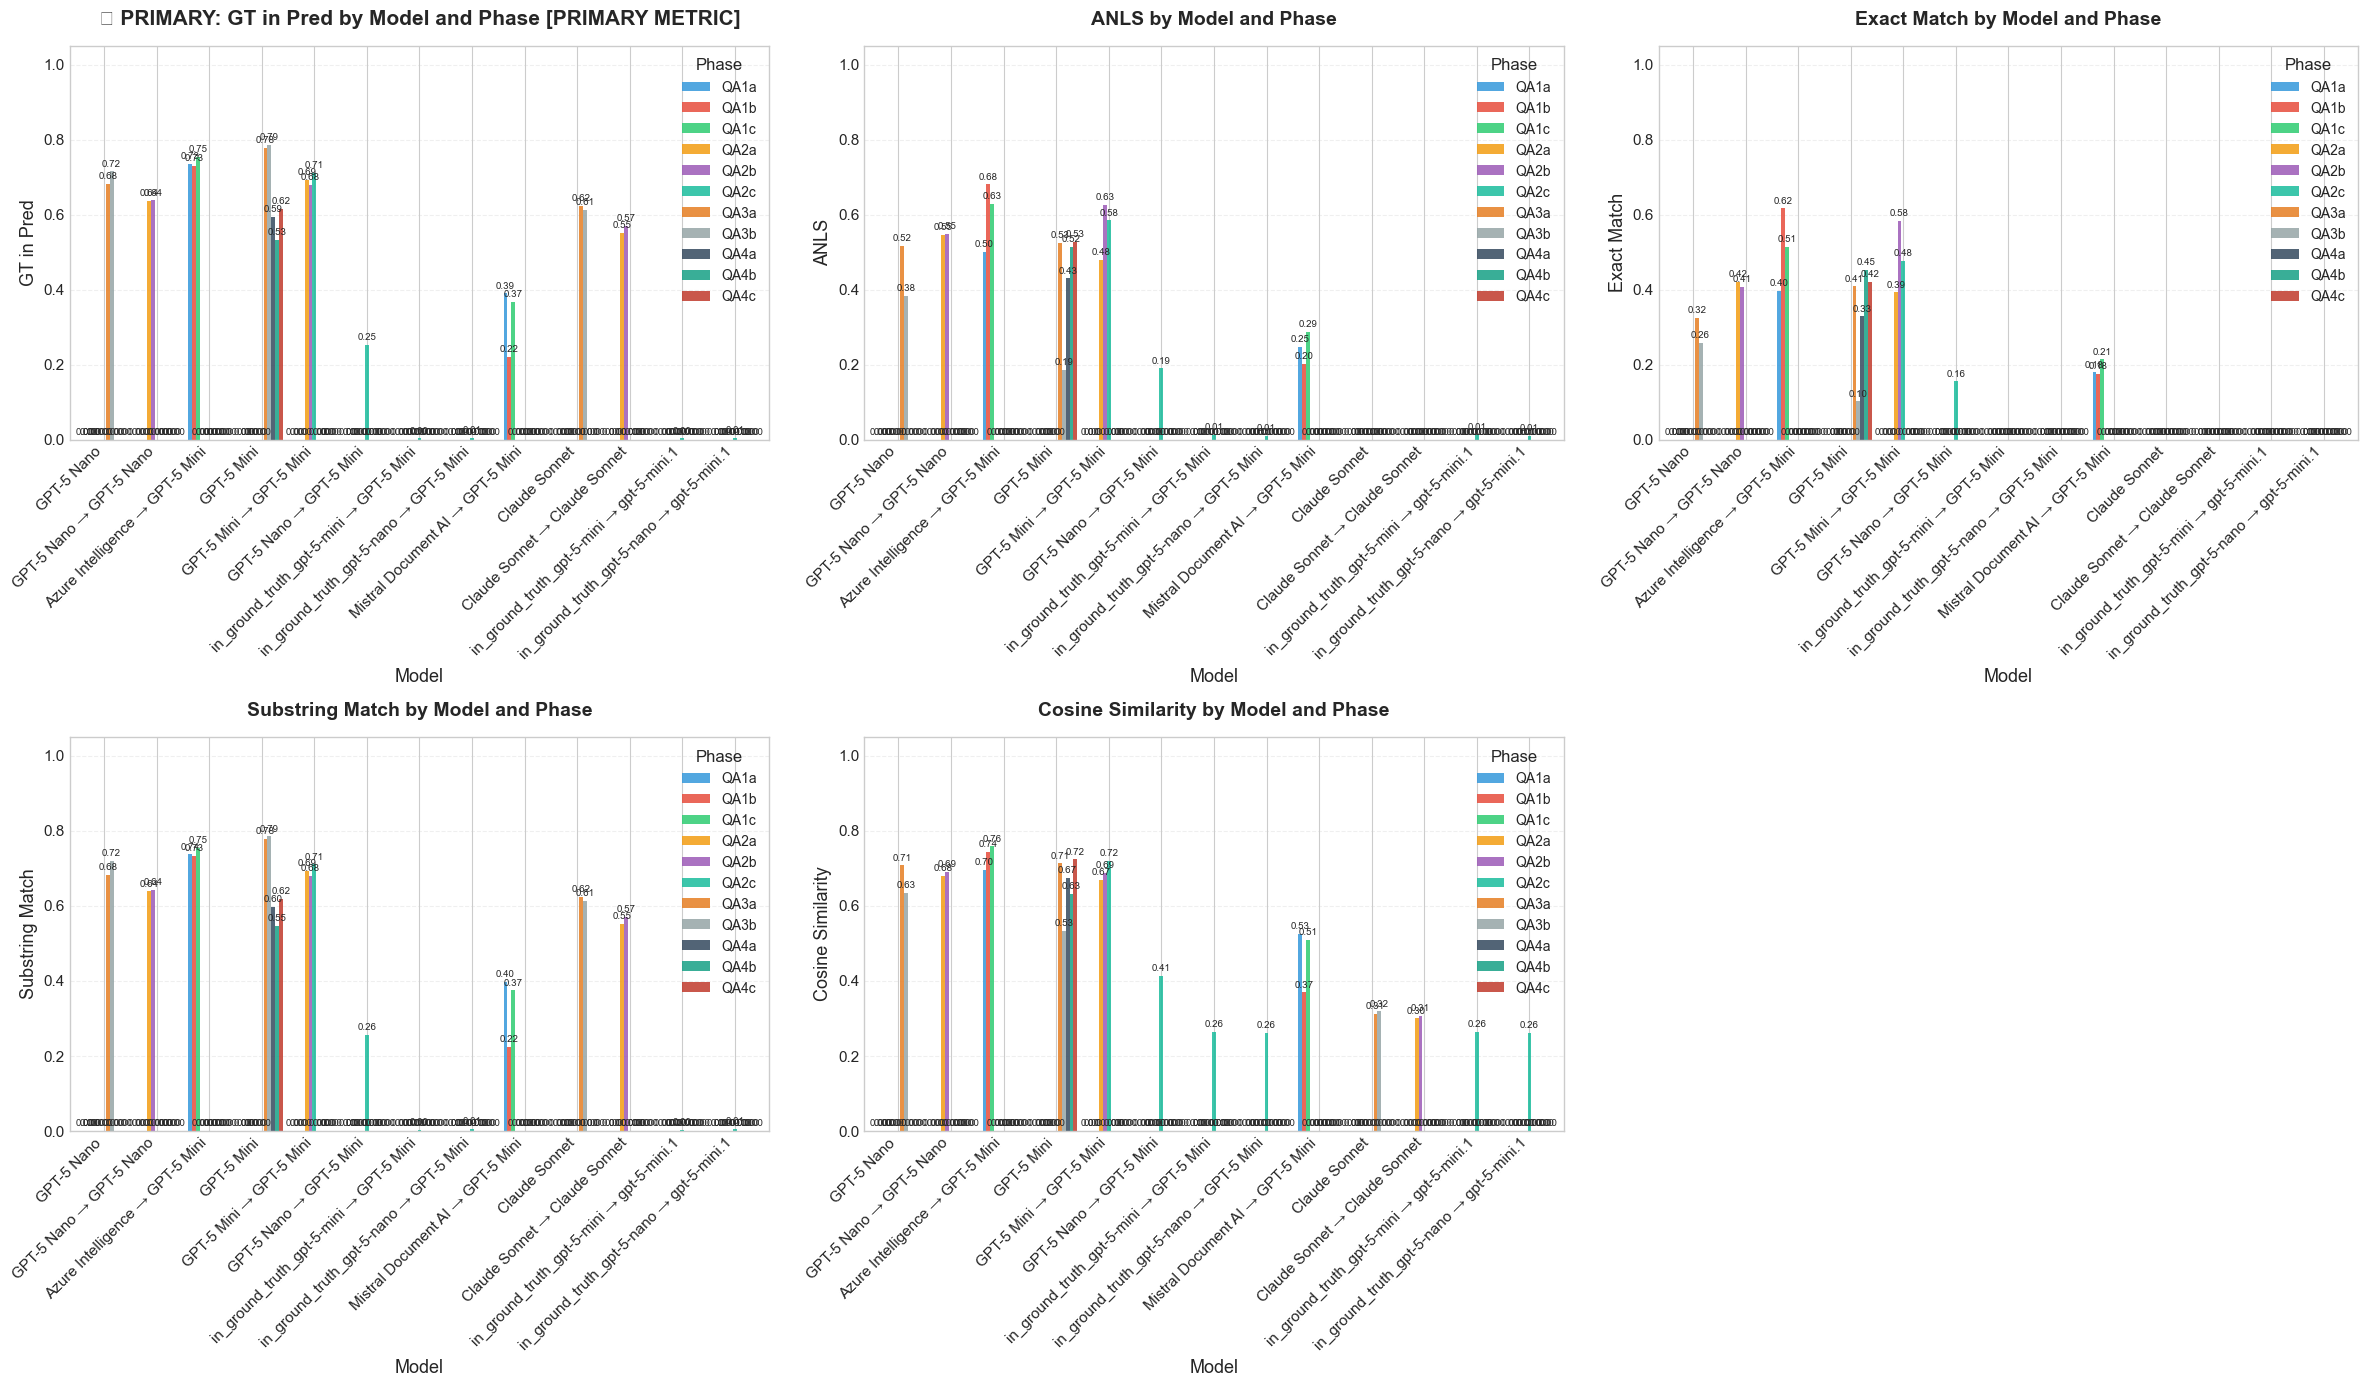


🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric


In [10]:
# Bar charts for each metric (PRIMARY METRIC FIRST)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

# PRIMARY METRIC FIRST, then secondary metrics
metrics_to_plot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6', '#34495e', '#16a085', '#c0392b']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Pivot data for grouped bar chart
    pivot_data = summary_df.pivot(index='Model', columns='Phase', values=metric)
    
    # Sort models
    pivot_data = pivot_data.reindex(sort_models(pivot_data.index.tolist()))
    
    pivot_data.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_data.columns)], alpha=0.85, width=0.8)
    
    # Emphasize primary metric
    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
    title_suffix = " [PRIMARY METRIC]" if metric == 'GT in Pred' else ""
    
    ax.set_title(f'{title_prefix}{metric} by Model and Phase{title_suffix}', 
                fontsize=15 if metric == 'GT in Pred' else 14, 
                fontweight='bold', pad=15)
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.legend(title='Phase', title_fontsize=12, fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_xticklabels([get_model_display_name(m) for m in pivot_data.index], rotation=45, ha='right')
    ax.set_ylim(0, 1.05)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)

# Hide last subplot if not needed
if len(metrics_to_plot) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

print("\n🎯 Note: 'GT in Pred' (Ground Truth in Prediction) is the PRIMARY metric")

## 7. Visualizations - Bar Charts

Compare all metrics across models and phases.

Calculating per-sample metrics for box plots (using only valid rows)...


Phase QA1a:   0%|          | 0/2 [00:00<?, ?it/s]

Phase QA1b:   0%|          | 0/2 [00:00<?, ?it/s]

Phase QA1c:   0%|          | 0/2 [00:00<?, ?it/s]

Phase QA2a:   0%|          | 0/3 [00:00<?, ?it/s]

...

Phase QA3a:   0%|          | 0/3 [00:00<?, ?it/s]

Phase QA3b:   0%|          | 0/3 [00:00<?, ?it/s]

Phase QA4a:   0%|          | 0/1 [00:00<?, ?it/s]

Phase QA4b:   0%|          | 0/1 [00:00<?, ?it/s]

Phase QA4c:   0%|          | 0/1 [00:00<?, ?it/s]

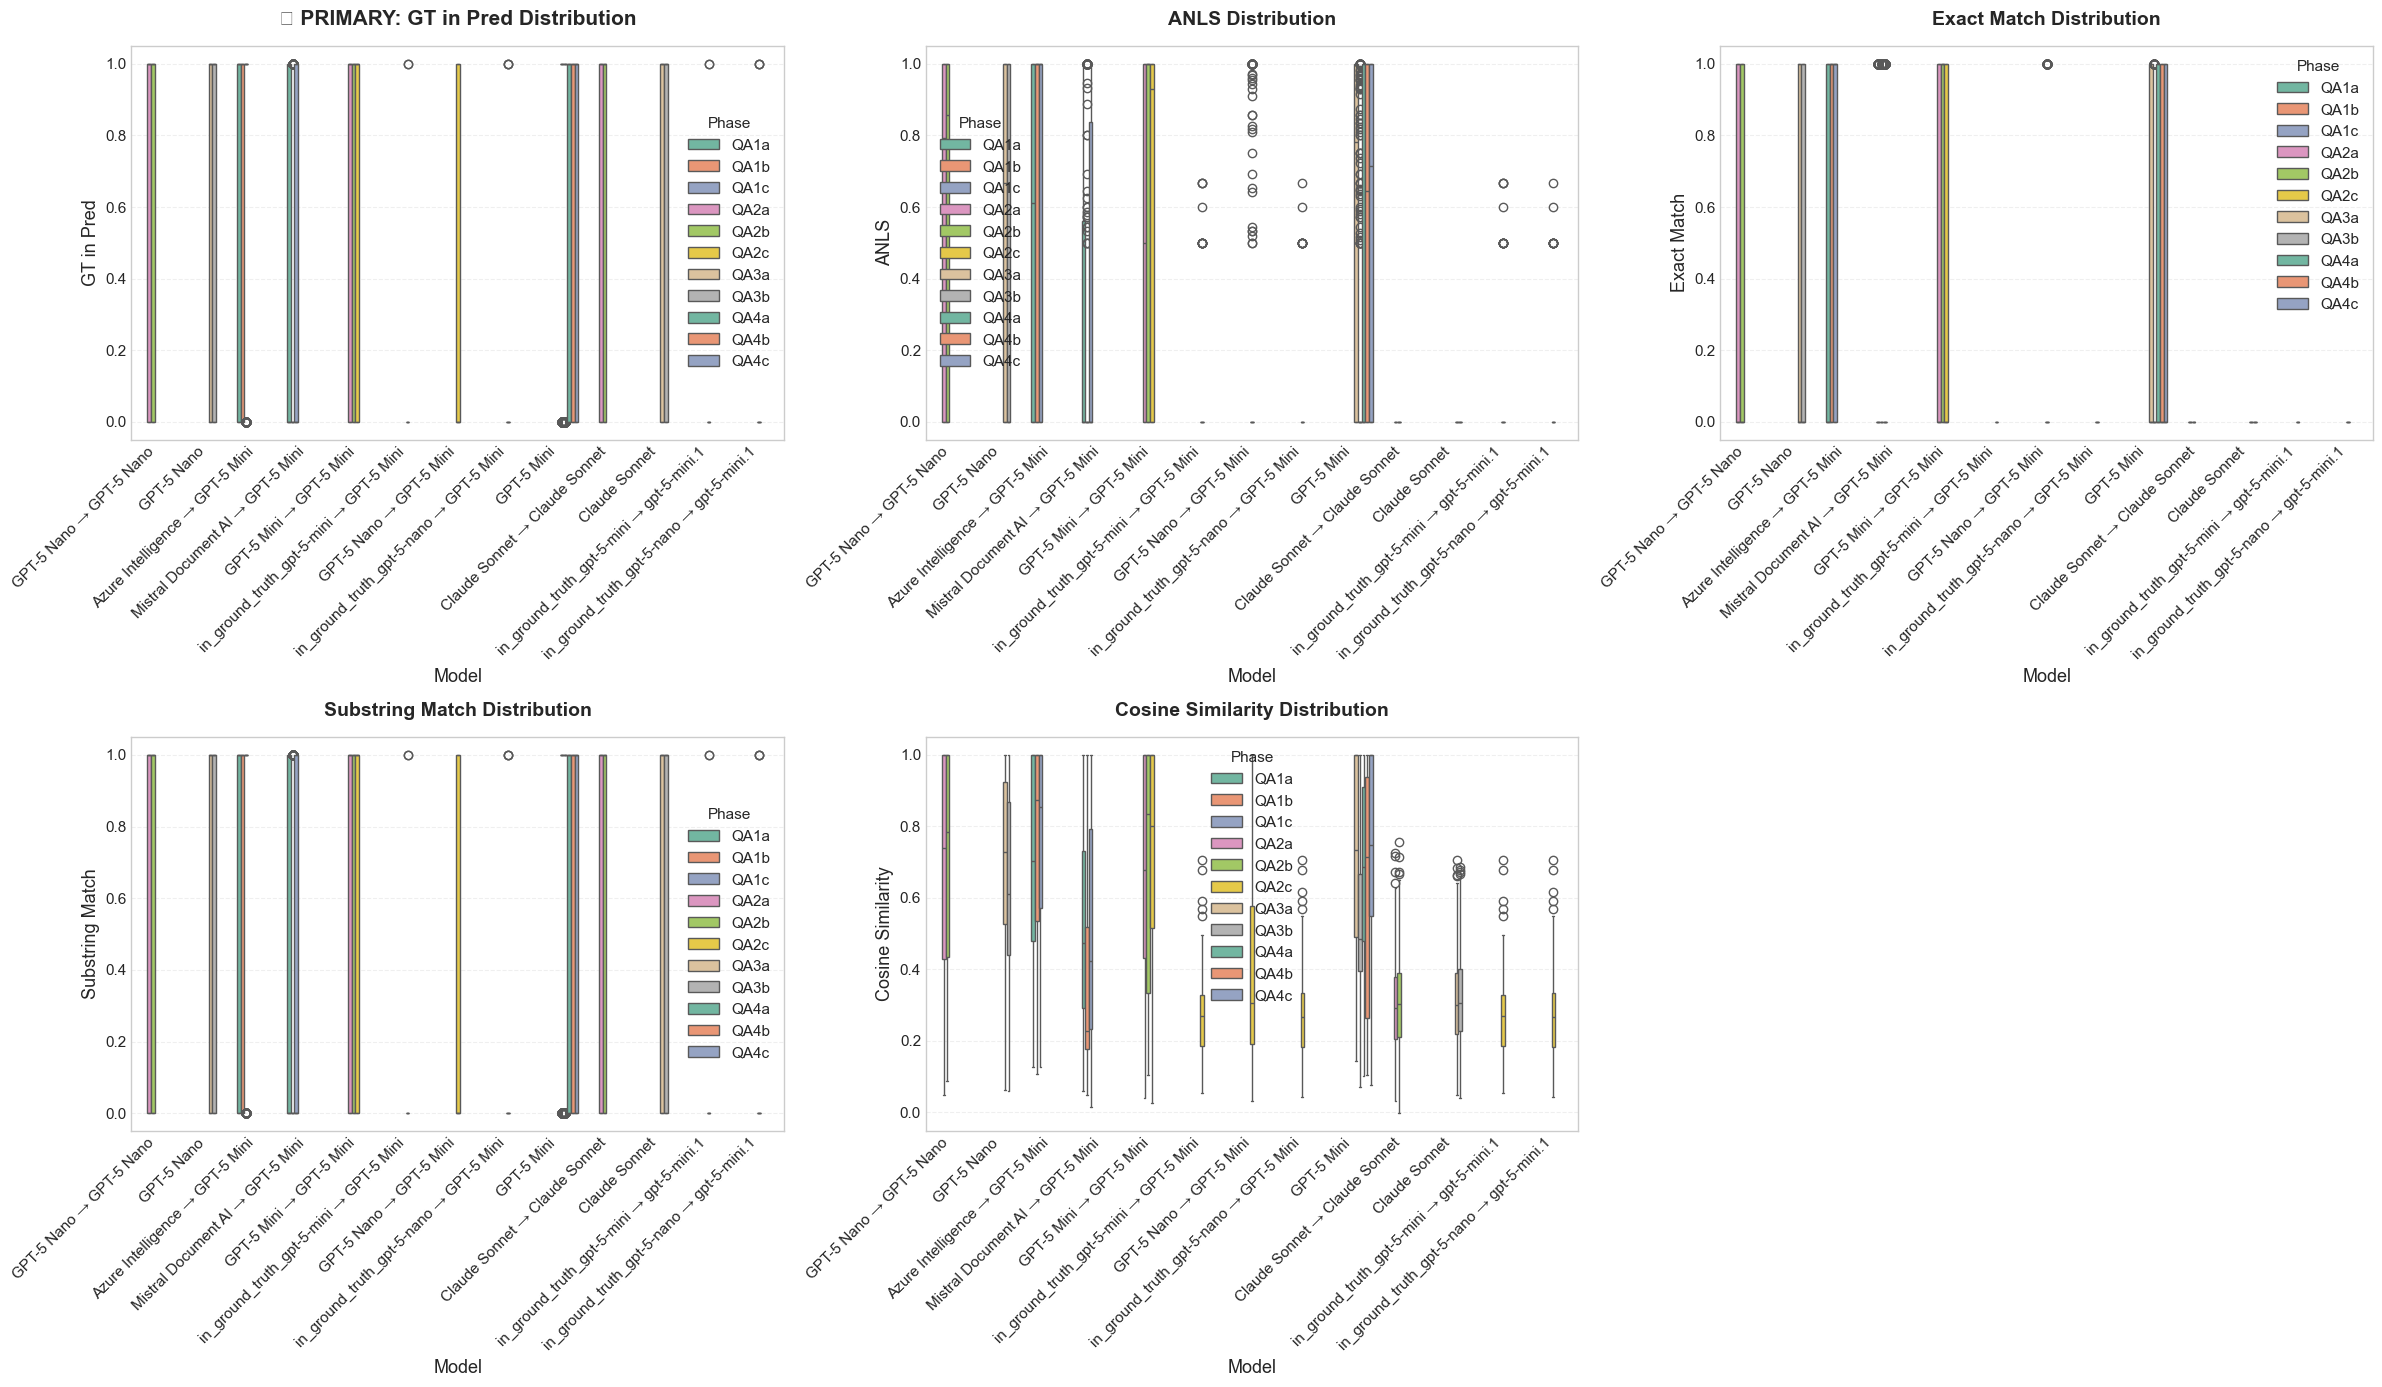


🎯 Note: Distributions show only valid samples (empty/error rows excluded)


In [11]:
# Calculate per-sample metrics for box plots
sample_metrics_data = []

print("Calculating per-sample metrics for box plots (using only valid rows)...")
for phase, df in phase_dfs.items():
    pred_cols = [col for col in df.columns if col.startswith('prediction_')]
    
    for pred_col in tqdm(pred_cols, desc=f"Phase {phase}", leave=False):
        model = pred_col.replace('prediction_', '')
        err_col = f'error_{model}'
        
        # Filter to only valid rows
        for _, row in df.iterrows():
            if not is_valid_row(row, pred_col, err_col):
                continue  # Skip invalid rows
            
            ground_truths = parse_ground_truths(row['ground_truths'])
            metrics = calculate_qa_metrics(
                row[pred_col], ground_truths, phase, 
                row['sample_id'], model, embedding_manager
            )
            
            sample_metrics_data.append({
                'Phase': phase,
                'Model': model,
                'GT in Pred': metrics['gt_in_pred'],  # PRIMARY METRIC
                'ANLS': metrics['anls'],
                'Exact Match': metrics['exact_match'],
                'Substring Match': metrics['substring_match'],
                'Cosine Similarity': metrics['cosine_similarity']
            })

sample_metrics_df = pd.DataFrame(sample_metrics_data)

# Create box plots (PRIMARY METRIC FIRST)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

metrics_for_boxplot = ['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match', 'Cosine Similarity']

for idx, metric in enumerate(metrics_for_boxplot):
    ax = axes[idx]
    
    # Create box plot
    sample_metrics_df_sorted = sample_metrics_df.copy()
    sample_metrics_df_sorted['Model'] = pd.Categorical(
        sample_metrics_df_sorted['Model'],
        categories=sort_models(sample_metrics_df_sorted['Model'].unique().tolist()),
        ordered=True
    )
    
    sns.boxplot(data=sample_metrics_df_sorted, x='Model', y=metric, hue='Phase', ax=ax, palette='Set2')
    
    # Emphasize primary metric
    title_prefix = "🎯 PRIMARY: " if metric == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric} Distribution', 
                fontsize=15 if metric == 'GT in Pred' else 14, 
                fontweight='bold', pad=15)
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(title='Phase', loc='best')

# Hide last subplot if not needed
if len(metrics_for_boxplot) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

print("\n🎯 Note: Distributions show only valid samples (empty/error rows excluded)")

## 8. Visualizations - Box Plots

Distribution analysis showing variance and outliers.

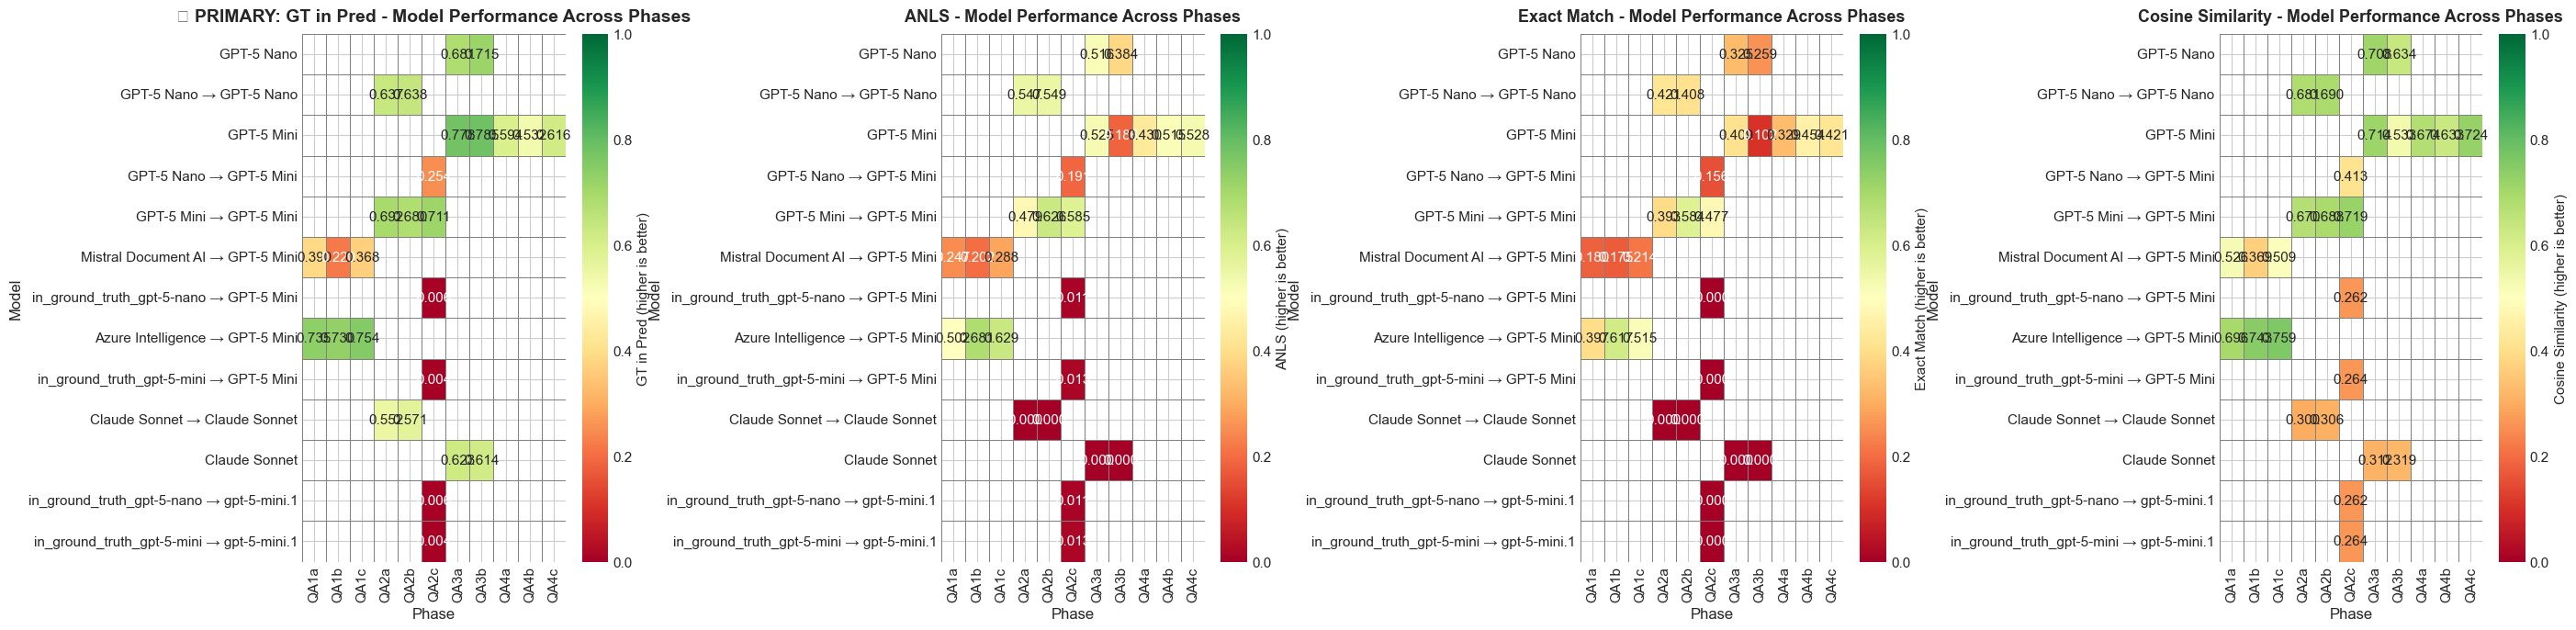


🎯 Note: 'GT in Pred' heatmap shows PRIMARY metric performance


In [12]:
# Create heatmaps for key metrics (PRIMARY METRIC FIRST)
metrics_to_show = ['GT in Pred', 'ANLS', 'Exact Match', 'Cosine Similarity']
fig, axes = plt.subplots(1, len(metrics_to_show), figsize=(7 * len(metrics_to_show), 7))

if len(metrics_to_show) == 1:
    axes = [axes]

for idx, metric_name in enumerate(metrics_to_show):
    ax = axes[idx]
    
    # Create heatmap data: rows = models, columns = phases
    heatmap_data = []
    model_names = []
    phase_names = list(metrics_results.keys())
    
    # Get all unique models across all phases and sort them
    all_models = set()
    for phase_models in metrics_results.values():
        all_models.update(phase_models.keys())
    all_models = sort_models(list(all_models))
    
    # Build heatmap data
    for model in all_models:
        row_data = []
        for phase in phase_names:
            if model in metrics_results[phase]:
                # Map metric name to key
                metric_key = metric_name.lower().replace(' ', '_')
                value = metrics_results[phase][model].get(metric_key, np.nan)
                row_data.append(value)
            else:
                row_data.append(np.nan)
        
        heatmap_data.append(row_data)
        model_names.append(model)
    
    heatmap_df = pd.DataFrame(
        heatmap_data,
        index=[get_model_display_name(m) for m in model_names],
        columns=phase_names
    )
    
    # Use colormap: green for good, red for bad (all QA metrics: higher is better)
    cmap = 'RdYlGn'
    cbar_label = f'{metric_name} (higher is better)'
    
    sns.heatmap(heatmap_df, annot=True, fmt='.3f', cmap=cmap, 
                ax=ax, cbar_kws={'label': cbar_label}, 
                vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
    
    # Emphasize primary metric in title
    title_prefix = "🎯 PRIMARY: " if metric_name == 'GT in Pred' else ""
    ax.set_title(f'{title_prefix}{metric_name} - Model Performance Across Phases', 
                fontsize=14 if metric_name == 'GT in Pred' else 13, 
                fontweight='bold', pad=10)
    ax.set_xlabel('Phase', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

print("\n🎯 Note: 'GT in Pred' heatmap shows PRIMARY metric performance")

## 9. Visualizations - Heatmaps

Model × Phase performance heatmaps.

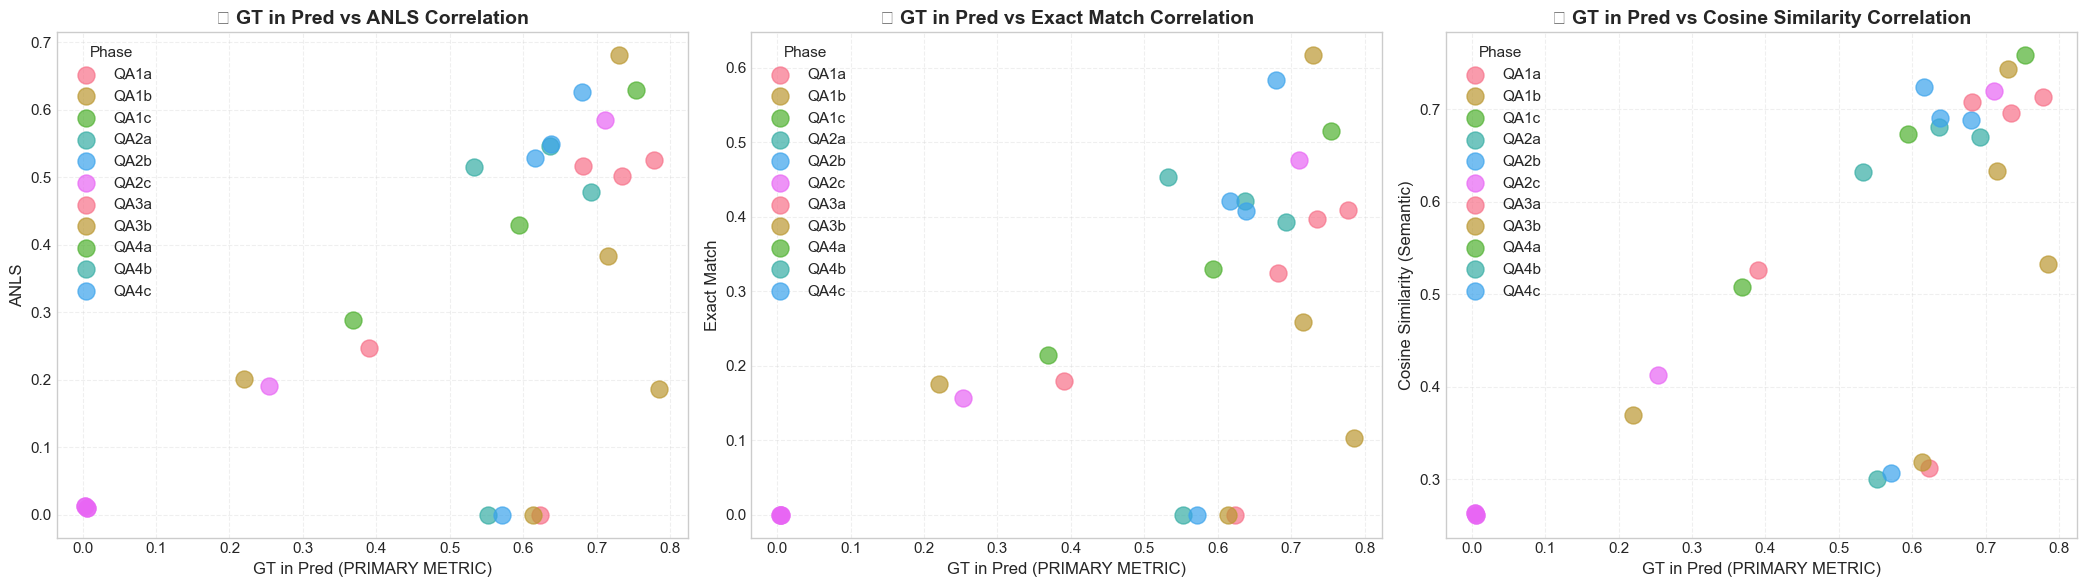


🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)


In [13]:
# Scatter plots: GT in Pred (PRIMARY) vs other metrics
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# GT in Pred vs ANLS
ax1 = axes[0]
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    ax1.scatter(phase_data['GT in Pred'], phase_data['ANLS'], 
               s=150, alpha=0.7, label=phase)

ax1.set_title('🎯 GT in Pred vs ANLS Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax1.set_ylabel('ANLS', fontsize=12)
ax1.legend(title='Phase', loc='best')
ax1.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Exact Match
ax2 = axes[1]
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    ax2.scatter(phase_data['GT in Pred'], phase_data['Exact Match'], 
               s=150, alpha=0.7, label=phase)

ax2.set_title('🎯 GT in Pred vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax2.set_ylabel('Exact Match', fontsize=12)
ax2.legend(title='Phase', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

# GT in Pred vs Cosine Similarity
ax3 = axes[2]
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    ax3.scatter(phase_data['GT in Pred'], phase_data['Cosine Similarity'], 
               s=150, alpha=0.7, label=phase)

ax3.set_title('🎯 GT in Pred vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('GT in Pred (PRIMARY METRIC)', fontsize=12)
ax3.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax3.legend(title='Phase', loc='best')
ax3.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n🎯 Note: All correlations are shown against the PRIMARY metric (GT in Pred)")

## 10. Visualizations - Scatter Plots

Correlation analysis between metrics.

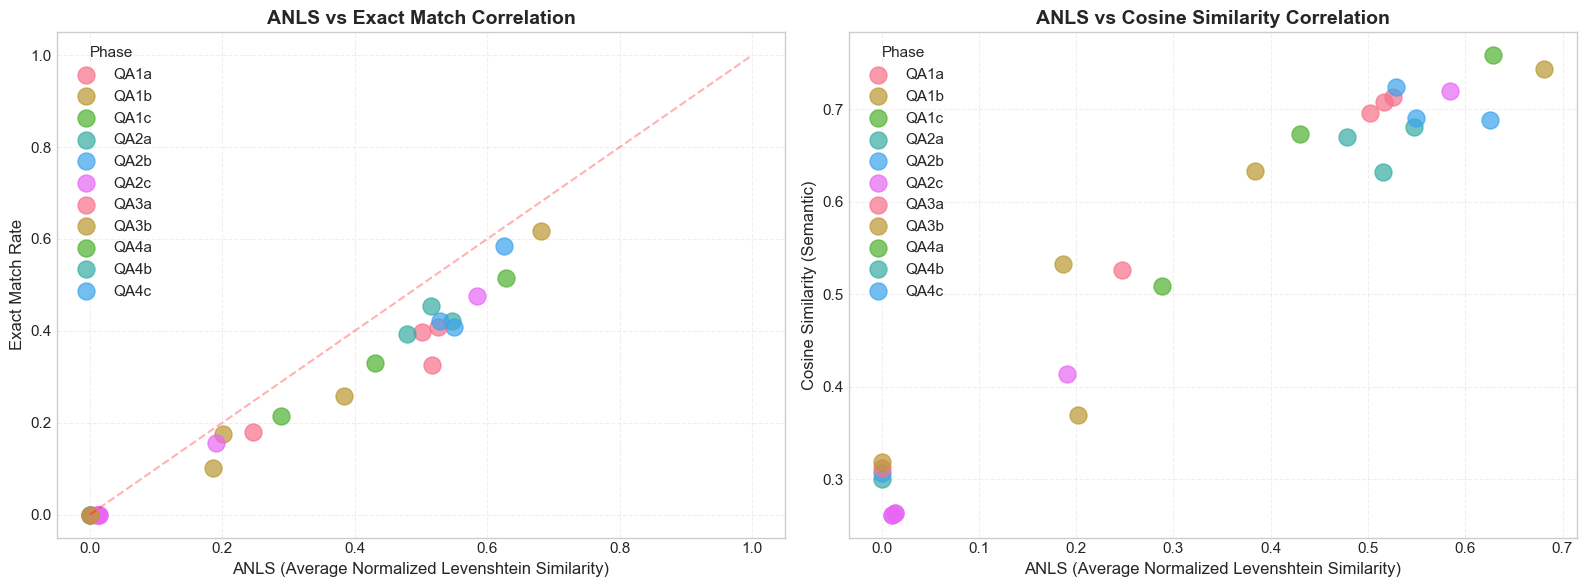

In [14]:
# Scatter plots: ANLS vs other metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ANLS vs Exact Match
ax1 = axes[0]
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    ax1.scatter(phase_data['ANLS'], phase_data['Exact Match'], 
               s=150, alpha=0.7, label=phase)

ax1.set_title('ANLS vs Exact Match Correlation', fontsize=14, fontweight='bold')
ax1.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax1.set_ylabel('Exact Match Rate', fontsize=12)
ax1.legend(title='Phase', loc='best')
ax1.grid(alpha=0.3, linestyle='--')
ax1.plot([0, 1], [0, 1], 'r--', alpha=0.3, label='ANLS=EM')

# ANLS vs Cosine Similarity
ax2 = axes[1]
for phase in summary_df['Phase'].unique():
    phase_data = summary_df[summary_df['Phase'] == phase]
    ax2.scatter(phase_data['ANLS'], phase_data['Cosine Similarity'], 
               s=150, alpha=0.7, label=phase)

ax2.set_title('ANLS vs Cosine Similarity Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('ANLS (Average Normalized Levenshtein Similarity)', fontsize=12)
ax2.set_ylabel('Cosine Similarity (Semantic)', fontsize=12)
ax2.legend(title='Phase', loc='best')
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 11. QA-Specific Analysis

Analyze question types, answer lengths, and QA-specific patterns.


Question Type Distribution (QA1a):
  What           :  205 questions ( 41.0%)
  Which          :  116 questions ( 23.2%)
  How            :   84 questions ( 16.8%)
  Other          :   49 questions (  9.8%)
  Who            :   22 questions (  4.4%)
  When           :   16 questions (  3.2%)
  Where          :    8 questions (  1.6%)


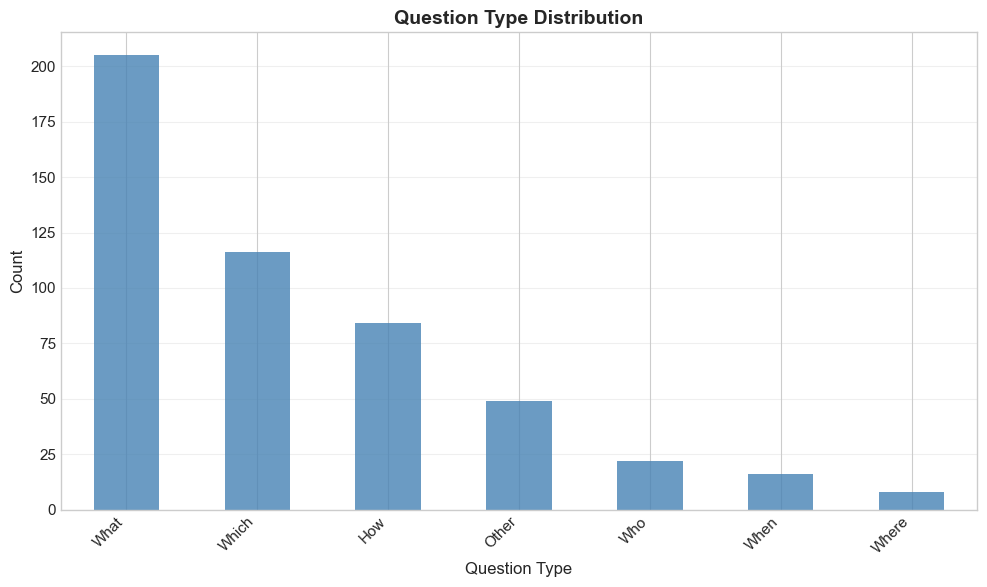

In [15]:
# Question type analysis
if len(phase_dfs) > 0:
    # Use first available phase for analysis
    analysis_phase = list(phase_dfs.keys())[0]
    df_analysis = phase_dfs[analysis_phase].copy()
    
    # Add question type categorization
    df_analysis['question_type'] = df_analysis['question'].apply(categorize_question_type)
    
    print(f"\nQuestion Type Distribution ({analysis_phase}):")
    print("=" * 80)
    type_counts = df_analysis['question_type'].value_counts()
    for qtype, count in type_counts.items():
        pct = count / len(df_analysis) * 100
        print(f"  {qtype:15s}: {count:4d} questions ({pct:5.1f}%)")
    
    # Visualize question types
    fig, ax = plt.subplots(figsize=(10, 6))
    type_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.set_title('Question Type Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Type', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

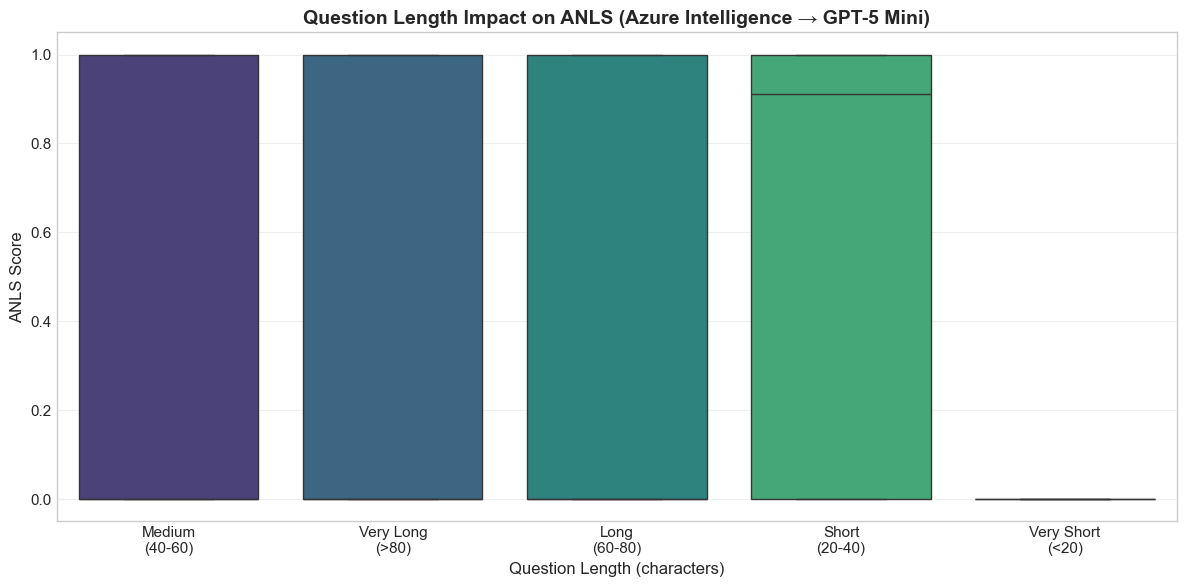

In [16]:
# Question length impact on performance
if len(phase_dfs) > 0:
    df_analysis['question_length'] = df_analysis['question'].astype(str).str.len()
    df_analysis['question_length_bin'] = pd.cut(
        df_analysis['question_length'],
        bins=[0, 20, 40, 60, 80, 1000],
        labels=['Very Short\n(<20)', 'Short\n(20-40)', 'Medium\n(40-60)', 'Long\n(60-80)', 'Very Long\n(>80)']
    )
    
    # Calculate ANLS for first model per length bin
    pred_col = [col for col in df_analysis.columns if col.startswith('prediction_')][0]
    model_name = pred_col.replace('prediction_', '')
    
    anls_by_length = []
    for _, row in df_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[pred_col]), ground_truths, threshold=0.5)
        anls_by_length.append({
            'question_length_bin': row['question_length_bin'],
            'anls': anls
        })
    
    anls_length_df = pd.DataFrame(anls_by_length)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=anls_length_df, x='question_length_bin', y='anls', ax=ax, palette='viridis')
    ax.set_title(f'Question Length Impact on ANLS ({get_model_display_name(model_name)})', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Question Length (characters)', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


🎯 PHASE STRATEGY COMPARISON (PRIMARY METRIC: GT in Pred)

QA1 (OCR+VLM):
  🎯 Mean GT in Pred: 0.5329 [PRIMARY]
     Mean ANLS: 0.4248
     Mean Exact Match: 0.3496
     Mean Substring Match: 0.5365
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  🎯 Mean GT in Pred: 0.3962 [PRIMARY]
     Mean ANLS: 0.2519
     Mean Exact Match: 0.2032
     Mean Substring Match: 0.3971
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  🎯 Mean GT in Pred: 0.6994 [PRIMARY]
     Mean ANLS: 0.2686
     Mean Exact Match: 0.1824
     Mean Substring Match: 0.7007
  Phases included: QA3a, QA3b

QA4 (Special Strategy):
  🎯 Mean GT in Pred: 0.5808 [PRIMARY]
     Mean ANLS: 0.4912
     Mean Exact Match: 0.4014
     Mean Substring Match: 0.5872
  Phases included: QA4a, QA4b, QA4c


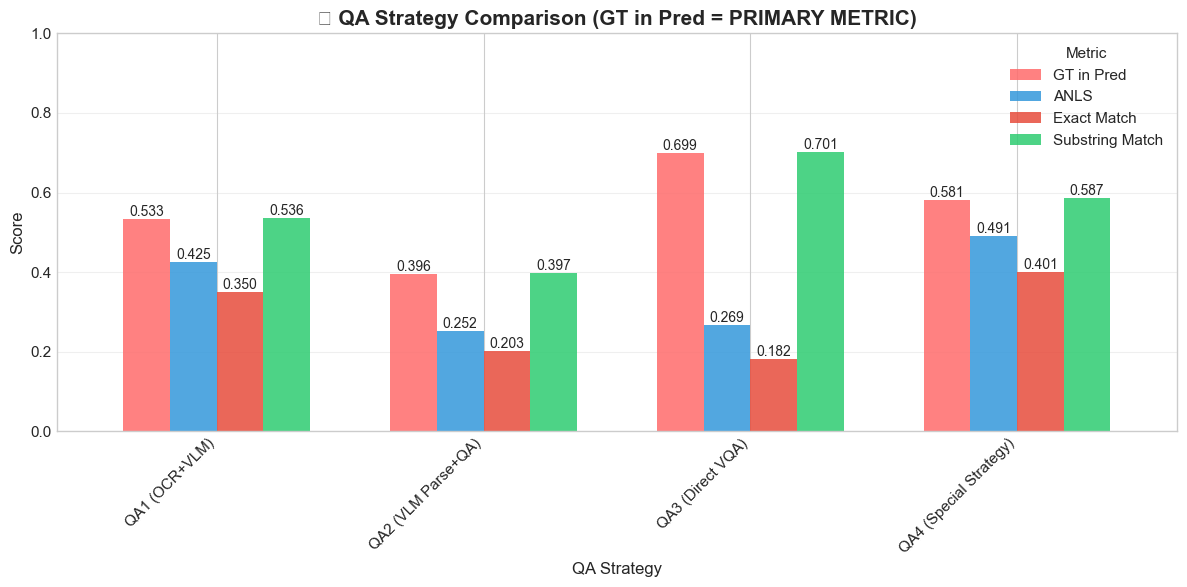


🏆 BEST STRATEGY (by GT in Pred - PRIMARY METRIC):
  QA3 (Direct VQA): GT in Pred = 0.6994


In [17]:
# Group phases by strategy (INCLUDING QA4)
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b'],
    'QA4 (Special Strategy)': ['QA4a', 'QA4b', 'QA4c']
}

print("\n" + "=" * 120)
print("🎯 PHASE STRATEGY COMPARISON (PRIMARY METRIC: GT in Pred)")
print("=" * 120)

strategy_results = []
for group_name, phases in phase_groups.items():
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_gt_in_pred = group_data['GT in Pred'].mean()
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  🎯 Mean GT in Pred: {avg_gt_in_pred:.4f} [PRIMARY]")
        print(f"     Mean ANLS: {avg_anls:.4f}")
        print(f"     Mean Exact Match: {avg_em:.4f}")
        print(f"     Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'GT in Pred': avg_gt_in_pred,  # PRIMARY FIRST
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison (PRIMARY METRIC FIRST)
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    strategy_df.set_index('Strategy')[['GT in Pred', 'ANLS', 'Exact Match', 'Substring Match']].plot(
        kind='bar', ax=ax, color=['#FF6B6B', '#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, width=0.7
    )
    ax.set_title('🎯 QA Strategy Comparison (GT in Pred = PRIMARY METRIC)', fontsize=15, fontweight='bold')
    ax.set_xlabel('QA Strategy', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(title='Metric', loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 120)
    print("🏆 BEST STRATEGY (by GT in Pred - PRIMARY METRIC):")
    best_strategy = strategy_df.loc[strategy_df['GT in Pred'].idxmax()]
    print(f"  {best_strategy['Strategy']}: GT in Pred = {best_strategy['GT in Pred']:.4f}")
    print("=" * 120)

## 12. Phase Comparison Analysis

Compare the four QA strategies: OCR+VLM, VLM Parse+QA, Direct VQA, and QA4 Special Strategy.


Phase Strategy Comparison:

QA1 (OCR+VLM):
  Mean ANLS: 0.4248
  Mean Exact Match: 0.3496
  Mean Substring Match: 0.5365
  Phases included: QA1a, QA1b, QA1c

QA2 (VLM Parse+QA):
  Mean ANLS: 0.2519
  Mean Exact Match: 0.2032
  Mean Substring Match: 0.3971
  Phases included: QA2a, QA2b, QA2c

QA3 (Direct VQA):
  Mean ANLS: 0.2686
  Mean Exact Match: 0.1824
  Mean Substring Match: 0.7007
  Phases included: QA3a, QA3b

QA4 (Special Strategy):
  Mean ANLS: 0.4912
  Mean Exact Match: 0.4014
  Mean Substring Match: 0.5872
  Phases included: QA4a, QA4b, QA4c


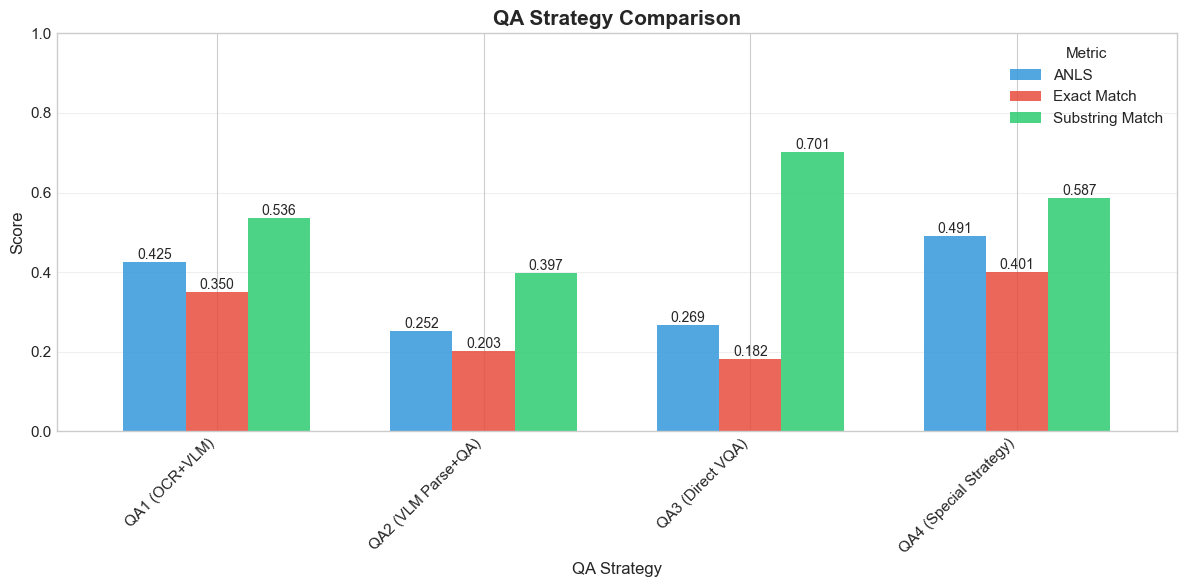

In [18]:
# Group phases by strategy (INCLUDING QA4)
phase_groups = {
    'QA1 (OCR+VLM)': ['QA1a', 'QA1b', 'QA1c'],
    'QA2 (VLM Parse+QA)': ['QA2a', 'QA2b', 'QA2c'],
    'QA3 (Direct VQA)': ['QA3a', 'QA3b'],
    'QA4 (Special Strategy)': ['QA4a', 'QA4b', 'QA4c']
}

print("\nPhase Strategy Comparison:")
print("=" * 100)

strategy_results = []
for group_name, phases in phase_groups.items():
    group_data = summary_df[summary_df['Phase'].isin(phases)]
    if len(group_data) > 0:
        avg_anls = group_data['ANLS'].mean()
        avg_em = group_data['Exact Match'].mean()
        avg_substring = group_data['Substring Match'].mean()
        
        print(f"\n{group_name}:")
        print(f"  Mean ANLS: {avg_anls:.4f}")
        print(f"  Mean Exact Match: {avg_em:.4f}")
        print(f"  Mean Substring Match: {avg_substring:.4f}")
        print(f"  Phases included: {', '.join(phases)}")
        
        strategy_results.append({
            'Strategy': group_name,
            'ANLS': avg_anls,
            'Exact Match': avg_em,
            'Substring Match': avg_substring
        })

# Visualize strategy comparison
if strategy_results:
    strategy_df = pd.DataFrame(strategy_results)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    strategy_df.set_index('Strategy')[['ANLS', 'Exact Match', 'Substring Match']].plot(
        kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.85, width=0.7
    )
    ax.set_title('QA Strategy Comparison', fontsize=15, fontweight='bold')
    ax.set_xlabel('QA Strategy', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.legend(title='Metric', loc='best', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.0)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10)
    
    plt.tight_layout()
    plt.show()

## 13. Sample-Level Error Analysis

Identify easiest and hardest questions to understand error patterns.

In [19]:
# Analyze best and worst performing samples
if len(phase_dfs) > 0:
    analysis_phase = list(phase_dfs.keys())[0]
    df_error_analysis = phase_dfs[analysis_phase].copy()
    
    # Get first model for analysis
    pred_cols = [col for col in df_error_analysis.columns if col.startswith('prediction_')]
    first_model = pred_cols[0].replace('prediction_', '')
    
    # Calculate ANLS for each sample
    anls_scores = []
    for _, row in df_error_analysis.iterrows():
        ground_truths = parse_ground_truths(row['ground_truths'])
        anls = compute_anls(str(row[f'prediction_{first_model}']), ground_truths, threshold=0.5)
        anls_scores.append(anls)
    
    df_error_analysis['anls'] = anls_scores
    
    # Get best and worst samples
    best_samples = df_error_analysis.nlargest(10, 'anls')
    worst_samples = df_error_analysis.nsmallest(10, 'anls')
    
    print("\n" + "="*120)
    print(f"EASIEST QUESTIONS (Highest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in best_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")
    
    print("\n" + "="*120)
    print(f"HARDEST QUESTIONS (Lowest ANLS) - Model: {get_model_display_name(first_model)}")
    print("="*120)
    
    for _, row in worst_samples.iterrows():
        print(f"\nSample: {row['sample_id']} | ANLS: {row['anls']:.4f}")
        print(f"Question: {str(row['question'])[:100]}..." if len(str(row['question'])) > 100 else f"Question: {row['question']}")
        
        ground_truths = parse_ground_truths(row['ground_truths'])
        gt_display = ', '.join([f'"{gt}"' for gt in ground_truths[:3]])
        if len(ground_truths) > 3:
            gt_display += f" ... (+{len(ground_truths)-3} more)"
        print(f"Ground Truths: {gt_display}")
        
        pred_text = str(row[f'prediction_{first_model}'])
        print(f"Prediction: {pred_text[:100]}..." if len(pred_text) > 100 else f"Prediction: {pred_text}")


EASIEST QUESTIONS (Highest ANLS) - Model: Azure Intelligence → GPT-5 Mini

Sample: infovqa_mini_0002 | ANLS: 1.0000
Question: What percent of non-digitally mature healthcare providers do not use digital technologies to persona...
Ground Truths: "79%", "79"
Prediction: 79%

Sample: infovqa_mini_0003 | ANLS: 1.0000
Question: In which year Pele achieved his third World Cup?
Ground Truths: "1970"
Prediction: 1970

Sample: infovqa_mini_0004 | ANLS: 1.0000
Question: What % of US adults will develop a mental illness during their lifetime
Ground Truths: "50", "50%"
Prediction: 50%

Sample: infovqa_mini_0005 | ANLS: 1.0000
Question: What percentage of companies use social media for marketing?
Ground Truths: "89%", "89"
Prediction: 89%

Sample: infovqa_mini_0007 | ANLS: 1.0000
Question: What percent of help in Israel comes from charities and social services?
Ground Truths: "59%", "59"
Prediction: 59%

Sample: infovqa_mini_0010 | ANLS: 1.0000
Question: What percent of the U.S. working population

## 14. Inference Time Analysis

Analyze speed vs accuracy trade-offs.


Inference Time Summary:


,Phase,Model,Mean Time (ms),Median Time (ms)
1,QA1a,mistral_document_ai__gpt-5-mini,10401.340370,9317.458868
0,QA1a,azure_intelligence__gpt-5-mini,11438.414013,9392.899156
3,QA1b,mistral_document_ai__gpt-5-mini,8741.683615,7225.490332
2,QA1b,azure_intelligence__gpt-5-mini,9328.025235,8146.299958
4,QA1c,azure_intelligence__gpt-5-mini,10418.750820,9160.004377
5,QA1c,mistral_document_ai__gpt-5-mini,12306.591010,10879.001021
6,QA2a,claude_sonnet__claude_sonnet,17677.348289,16751.580000
7,QA2a,gpt-5-mini__gpt-5-mini,26016.009696,25697.860003
8,QA2a,gpt-5-nano__gpt-5-nano,47084.480919,45321.891904
9,QA2b,claude_sonnet__claude_sonnet,19305.836759,18570.524454


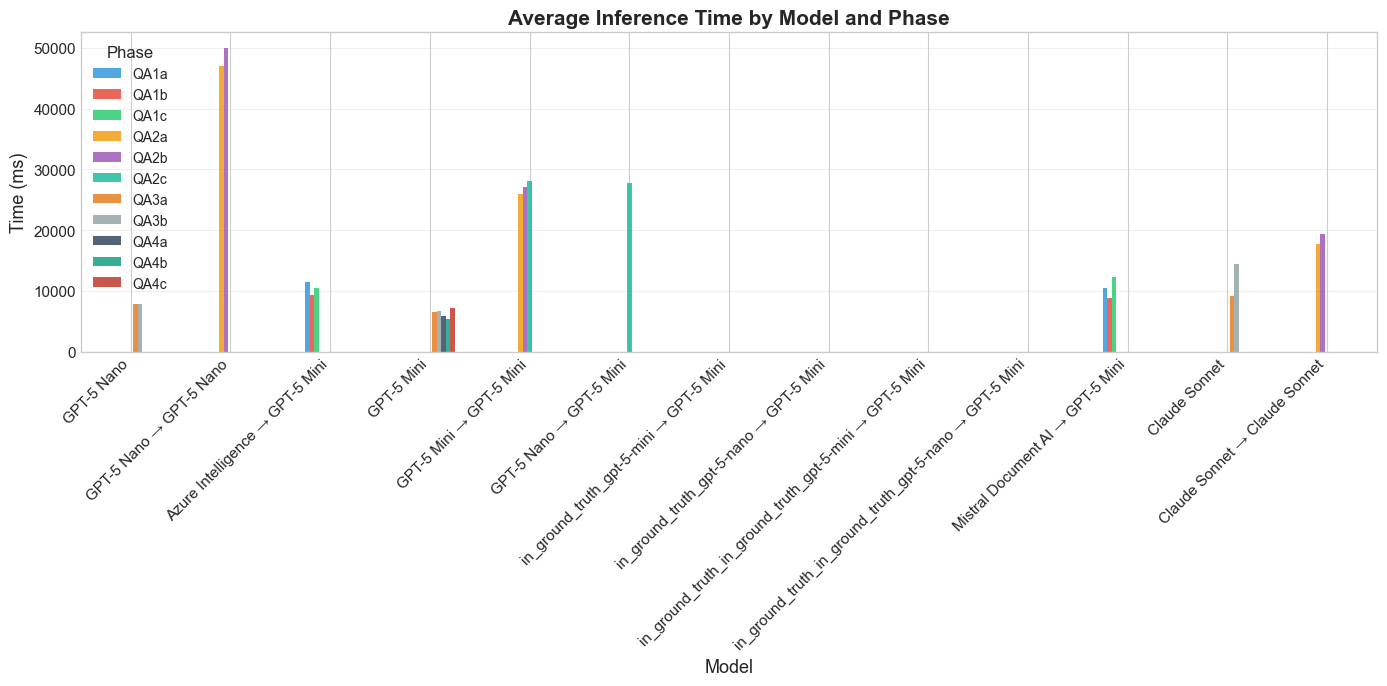

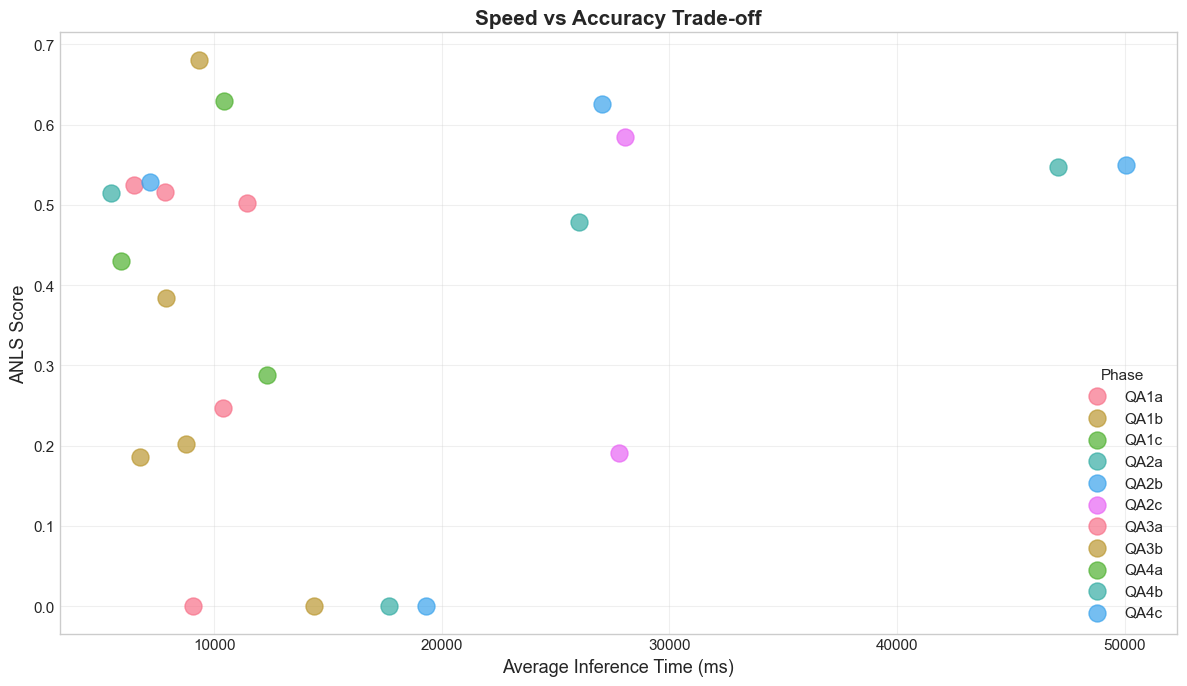

In [20]:
# Analyze inference times across models and phases
inference_data = []

for phase, df in phase_dfs.items():
    time_cols = [col for col in df.columns if col.startswith('inference_time_ms_')]
    
    for time_col in time_cols:
        model = time_col.replace('inference_time_ms_', '')
        
        mean_time = df[time_col].mean()
        median_time = df[time_col].median()
        
        inference_data.append({
            'Phase': phase,
            'Model': model,
            'Mean Time (ms)': mean_time,
            'Median Time (ms)': median_time
        })

if inference_data:
    inference_df = pd.DataFrame(inference_data)
    
    print("\nInference Time Summary:")
    print("="*120)
    display(inference_df.sort_values(['Phase', 'Mean Time (ms)']))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(14, 7))
    
    pivot_time = inference_df.pivot(index='Model', columns='Phase', values='Mean Time (ms)')
    pivot_time = pivot_time.reindex(sort_models(pivot_time.index.tolist()))
    pivot_time.plot(kind='bar', ax=ax, color=colors_palette[:len(pivot_time.columns)], alpha=0.85)
    
    ax.set_title('Average Inference Time by Model and Phase', fontsize=15, fontweight='bold')
    ax.set_xlabel('Model', fontsize=13)
    ax.set_ylabel('Time (ms)', fontsize=13)
    ax.legend(title='Phase', title_fontsize=12, fontsize=10, loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([get_model_display_name(t.get_text()) for t in ax.get_xticklabels()], 
                       rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Speed vs Accuracy scatter plot
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Merge inference time with ANLS scores
    speed_accuracy = pd.merge(
        inference_df[['Phase', 'Model', 'Mean Time (ms)']],
        summary_df[['Phase', 'Model', 'ANLS']],
        on=['Phase', 'Model']
    )
    
    for phase in speed_accuracy['Phase'].unique():
        phase_data = speed_accuracy[speed_accuracy['Phase'] == phase]
        ax.scatter(phase_data['Mean Time (ms)'], phase_data['ANLS'], 
                  s=150, alpha=0.7, label=phase)
    
    ax.set_title('Speed vs Accuracy Trade-off', fontsize=15, fontweight='bold')
    ax.set_xlabel('Average Inference Time (ms)', fontsize=13)
    ax.set_ylabel('ANLS Score', fontsize=13)
    ax.legend(title='Phase', loc='best')
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No inference time data available")

## 15. InfographicVQA-Specific Analysis

Analyze infographic-specific patterns: chart types, visual reasoning vs text extraction, and QA4 special strategy comparison.

In [21]:
# Analyze performance on infographic-specific patterns
print("\nInfographicVQA-Specific Analysis:")
print("=" * 100)
print("\nKey Findings:")
print("- Infographic questions involve charts, statistics, and visual design elements")
print("- Questions require both text extraction and visual reasoning")
print("- Chart types may include bar charts, pie charts, line graphs, and infographic layouts")
print("\nQA4 Special Strategy Comparison:")

# Compare QA4 with other strategies
if 'QA4a' in summary_df['Phase'].values or 'QA4b' in summary_df['Phase'].values or 'QA4c' in summary_df['Phase'].values:
    qa4_data = summary_df[summary_df['Phase'].str.startswith('QA4')]
    other_data = summary_df[~summary_df['Phase'].str.startswith('QA4')]
    
    print(f"\nQA4 Strategy Performance:")
    print(f"  Average GT in Pred: {qa4_data['GT in Pred'].mean():.4f} [PRIMARY]")
    print(f"  Average ANLS: {qa4_data['ANLS'].mean():.4f}")
    print(f"  Average Exact Match: {qa4_data['Exact Match'].mean():.4f}")
    
    print(f"\nOther Strategies (QA1-QA3) Performance:")
    print(f"  Average GT in Pred: {other_data['GT in Pred'].mean():.4f} [PRIMARY]")
    print(f"  Average ANLS: {other_data['ANLS'].mean():.4f}")
    print(f"  Average Exact Match: {other_data['Exact Match'].mean():.4f}")
    
    improvement = ((qa4_data['GT in Pred'].mean() - other_data['GT in Pred'].mean()) / other_data['GT in Pred'].mean()) * 100
    print(f"\n🎯 QA4 vs Others (GT in Pred): {improvement:+.1f}% {'improvement' if improvement > 0 else 'decline'}")
else:
    print("  No QA4 data available for comparison")

print("\nRecommendations for infographic QA:")
print("- Direct VQA (QA3) may excel at visual reasoning questions")
print("- OCR pipeline (QA1) can be effective for text-heavy infographics")
print("- Consider QA4 special strategy for complex chart understanding")
print("- Evaluate model performance on different chart types if metadata available")


InfographicVQA-Specific Analysis:

Key Findings:
- Infographic questions involve charts, statistics, and visual design elements
- Questions require both text extraction and visual reasoning
- Chart types may include bar charts, pie charts, line graphs, and infographic layouts

QA4 Special Strategy Comparison:

QA4 Strategy Performance:
  Average GT in Pred: 0.5808 [PRIMARY]
  Average ANLS: 0.4912
  Average Exact Match: 0.4014

Other Strategies (QA1-QA3) Performance:
  Average GT in Pred: 0.5062 [PRIMARY]
  Average ANLS: 0.2993
  Average Exact Match: 0.2346

🎯 QA4 vs Others (GT in Pred): +14.8% improvement

Recommendations for infographic QA:
- Direct VQA (QA3) may excel at visual reasoning questions
- OCR pipeline (QA1) can be effective for text-heavy infographics
- Consider QA4 special strategy for complex chart understanding
- Evaluate model performance on different chart types if metadata available


## 16. LLM Query Section

This section is a placeholder for analyzing the notebook outputs using an LLM.

### Key Questions to Investigate:

1. **Phase Strategy Performance:**
   - Which phase strategy works best? (QA1 vs QA2 vs QA3 vs QA4)
   - How does QA4 special strategy compare to standard approaches?
   - When should we use two-step pipeline vs direct VQA for infographics?

2. **Model Comparison:**
   - Which model performs best overall for infographic QA?
   - Are there trade-offs between different models (speed vs accuracy)?
   - Which model offers best balance for production use?

3. **Question Type Patterns:**
   - Which question types are easiest/hardest for infographics?
   - Do certain models excel at specific question types?
   - Are visual reasoning questions handled differently than text extraction?

4. **Infographic-Specific Insights:**
   - Performance on charts vs text-heavy infographics?
   - Visual reasoning vs data extraction accuracy?
   - Impact of infographic complexity on QA performance?

5. **Production Recommendations:**
   - Best model/phase combination for infographic QA?
   - When to use QA4 special strategy vs standard approaches?
   - Cost-effectiveness analysis (speed vs accuracy vs API cost)?

## 17. Save Embeddings Cache

Save any newly computed embeddings to disk for faster future runs.

In [22]:
# Save any remaining embeddings to disk for future use
print("\n📁 Finalizing embedding cache...")

if embedding_manager.modified_phases:
    print(f"Saving embeddings for modified phases: {embedding_manager.modified_phases}")
    
    for phase in embedding_manager.modified_phases:
        if phase in embedding_manager.cache:
            saved_file = save_embeddings_for_phase(
                dataset_name=DATASET_NAME,
                phase=phase,
                embeddings_dict=embedding_manager.cache[phase],
                embeddings_base_dir=EMBEDDINGS_DIR
            )
            print(f"✅ Saved: {saved_file.name}")
    
    print("\n✅ All embeddings have been persisted to disk!")
else:
    print("✅ No new embeddings to save (all from cache)")


📁 Finalizing embedding cache...
Saving embeddings for modified phases: {'QA4a', 'QA2c', 'QA3a', 'QA3b', 'QA1c', 'QA2b', 'QA2a', 'QA4c', 'QA4b', 'QA1b', 'QA1a'}
✅ Saved: QA4a_embeddings_text-embedding-3-large_20260131_181312.json
✅ Saved: QA2c_embeddings_text-embedding-3-large_20260131_181314.json
✅ Saved: QA3a_embeddings_text-embedding-3-large_20260131_181321.json
✅ Saved: QA3b_embeddings_text-embedding-3-large_20260131_181324.json
✅ Saved: QA1c_embeddings_text-embedding-3-large_20260131_181327.json
✅ Saved: QA2b_embeddings_text-embedding-3-large_20260131_181331.json
✅ Saved: QA2a_embeddings_text-embedding-3-large_20260131_181335.json
✅ Saved: QA4c_embeddings_text-embedding-3-large_20260131_181339.json
✅ Saved: QA4b_embeddings_text-embedding-3-large_20260131_181340.json
✅ Saved: QA1b_embeddings_text-embedding-3-large_20260131_181342.json
✅ Saved: QA1a_embeddings_text-embedding-3-large_20260131_181346.json

✅ All embeddings have been persisted to disk!


## 18. Conclusion

This notebook provides a comprehensive analysis of InfographicVQA question answering performance across multiple models and QA strategies.

**Key Deliverables:**
- Quantitative QA metrics (GT in Pred [PRIMARY], ANLS, EM, Substring Match, Cosine Similarity) for all models
- Phase strategy comparison (OCR+VLM vs VLM Parse+QA vs Direct VQA vs QA4 Special Strategy)
- Visual comparisons across phases and models
- Question type and answer length analysis
- Sample-level error analysis identifying strengths and weaknesses
- Inference time benchmarks and speed vs accuracy trade-offs
- Infographic-specific analysis: visual reasoning, chart types, QA4 strategy evaluation

**Next Steps:**
- Use LLM to generate natural language insights from results
- Identify specific question types or infographic layouts that cause issues
- Recommend optimal model selection strategy for infographic QA
- Investigate impact of chart complexity on QA performance
- Explore QA4 special strategy effectiveness for different infographic types
- Compare visual reasoning vs text extraction performance across models